데이터셋 준비

X shape: (1600, 784)
Inferred shape: 28x28x1


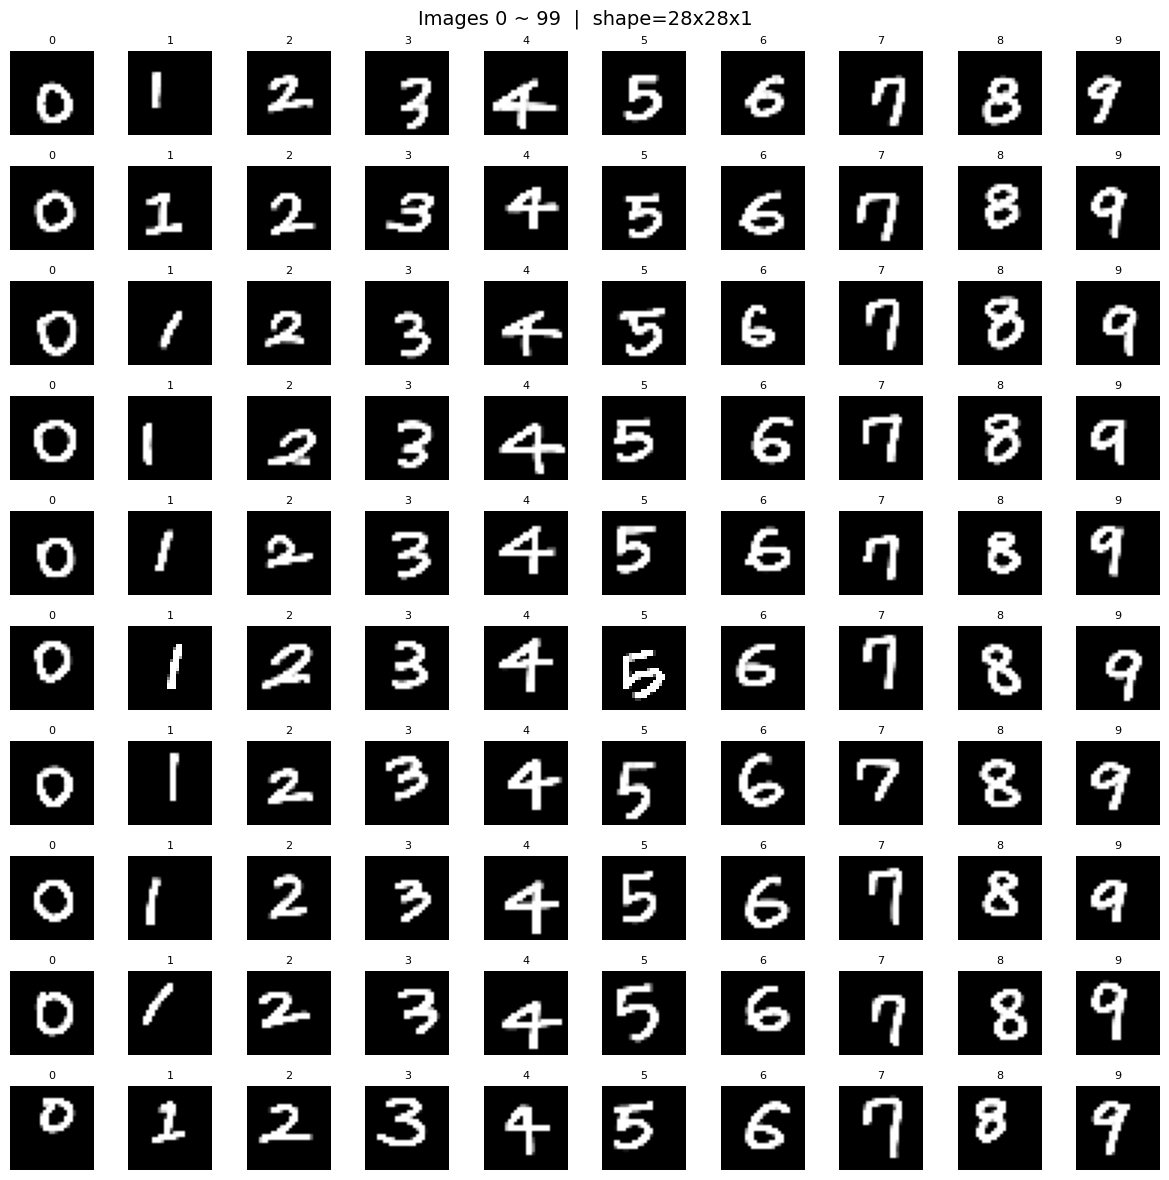

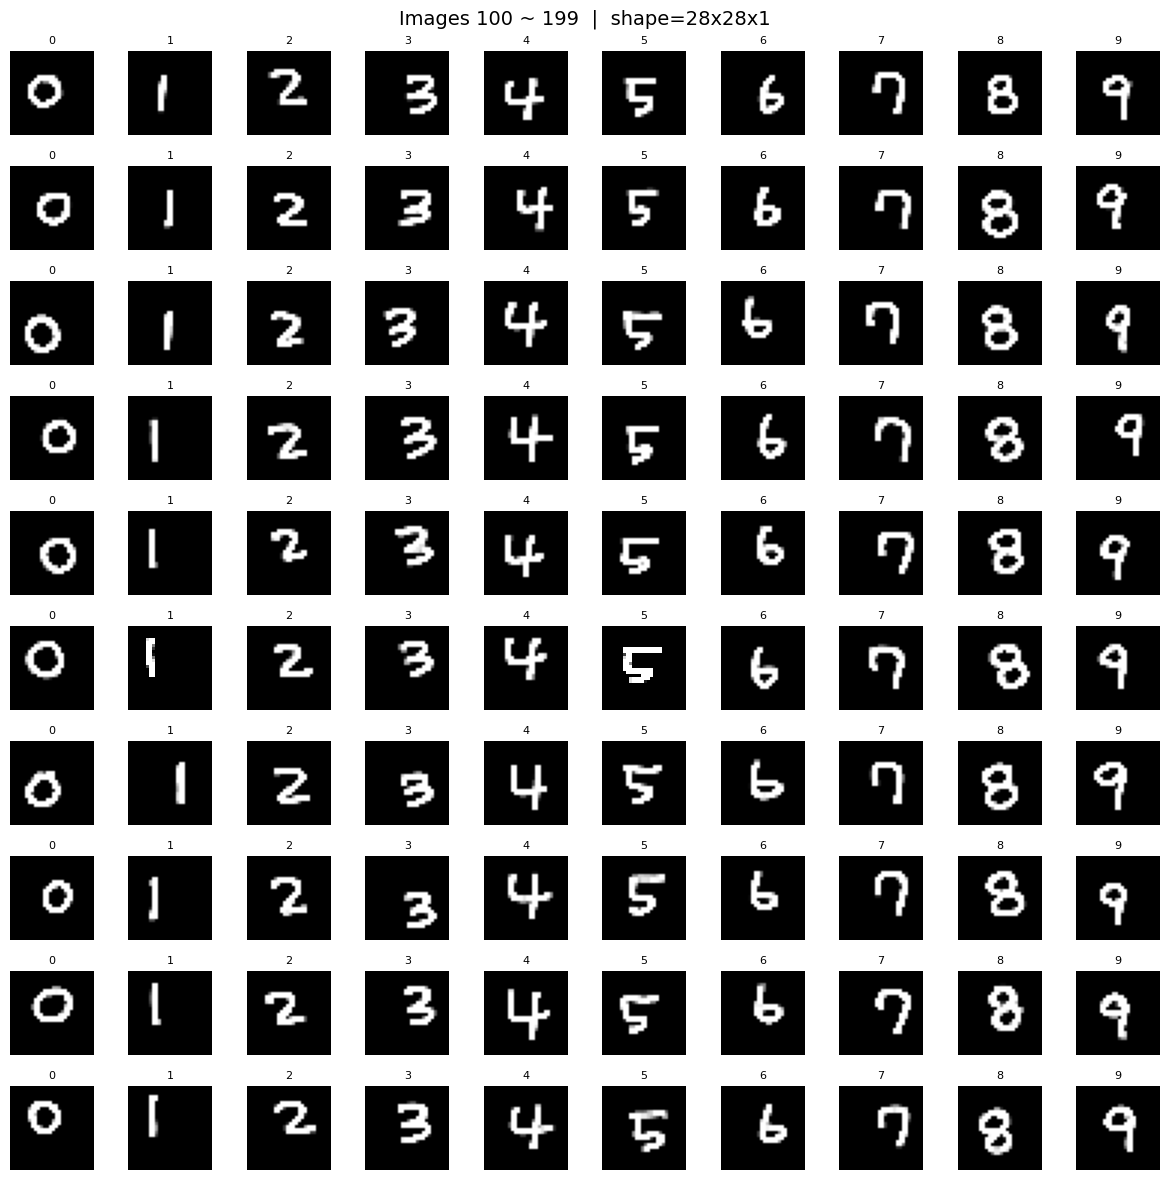

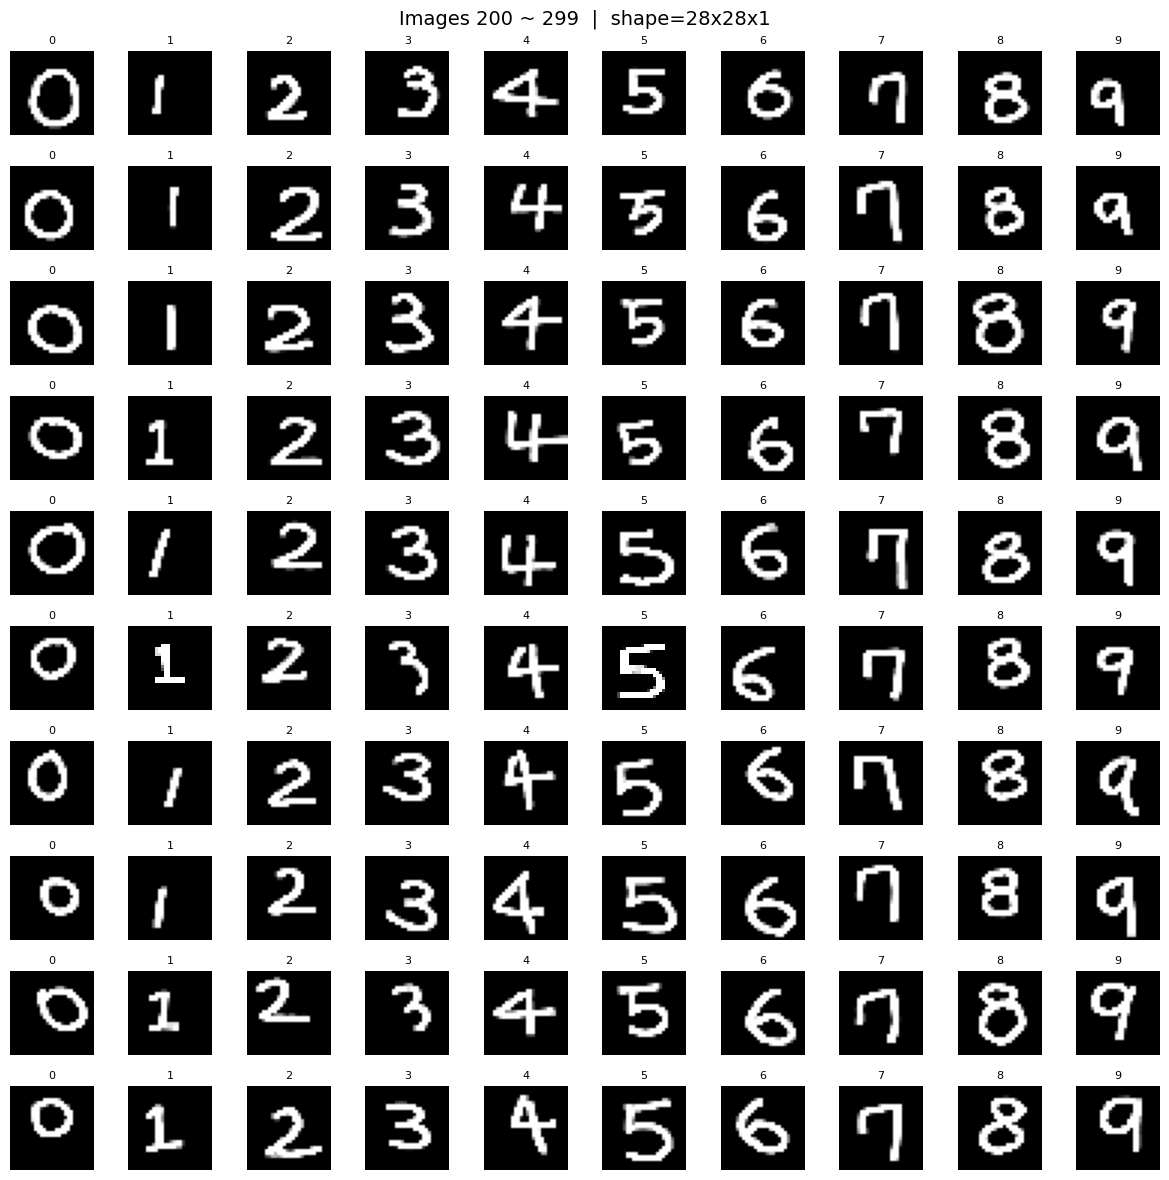

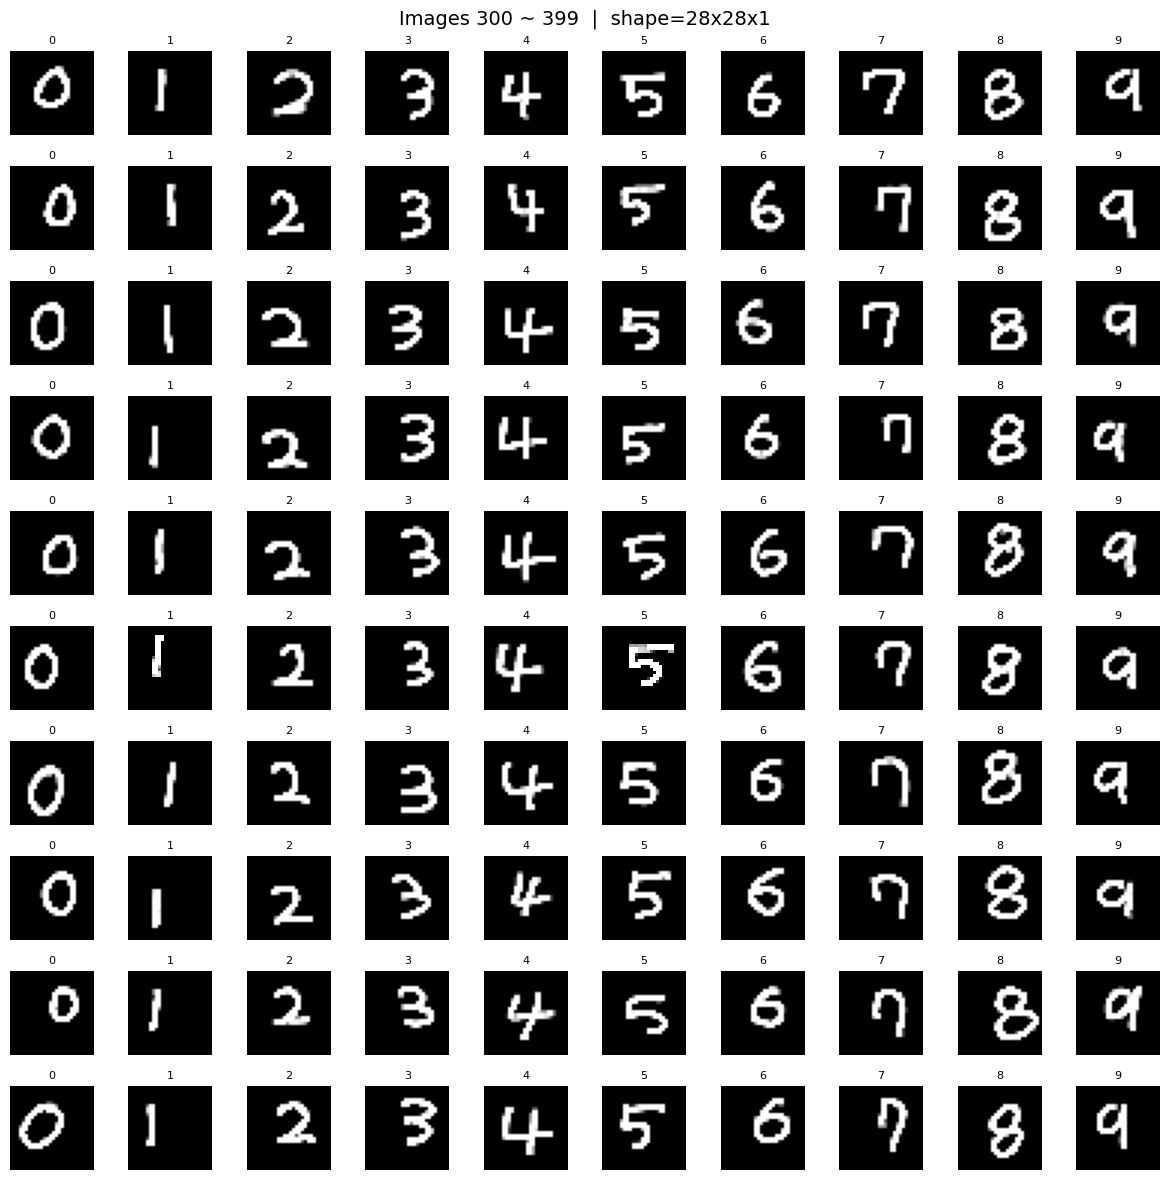

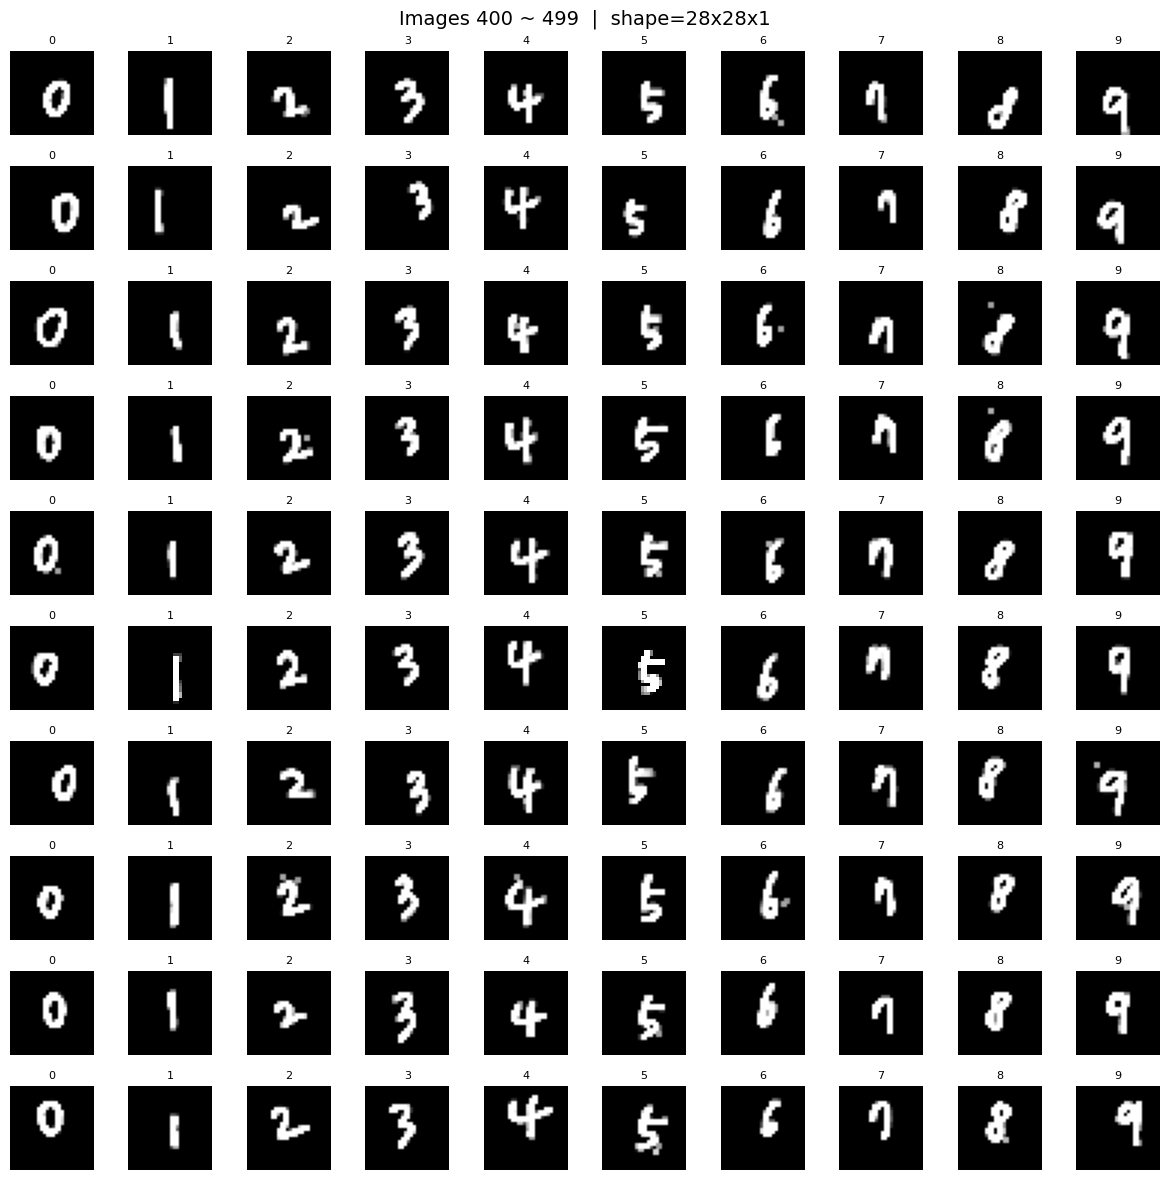

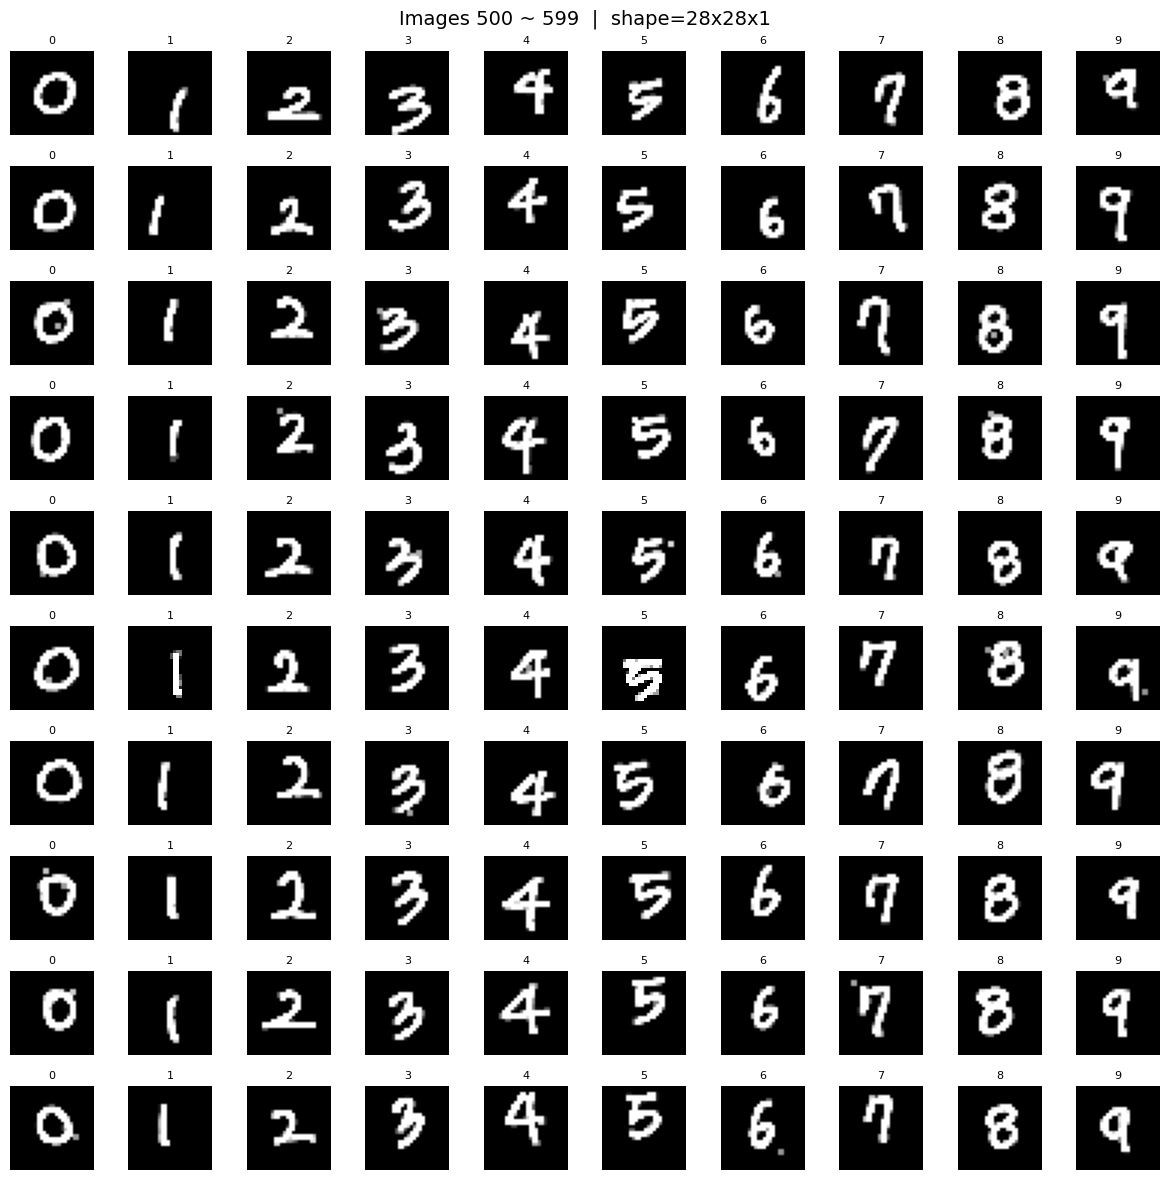

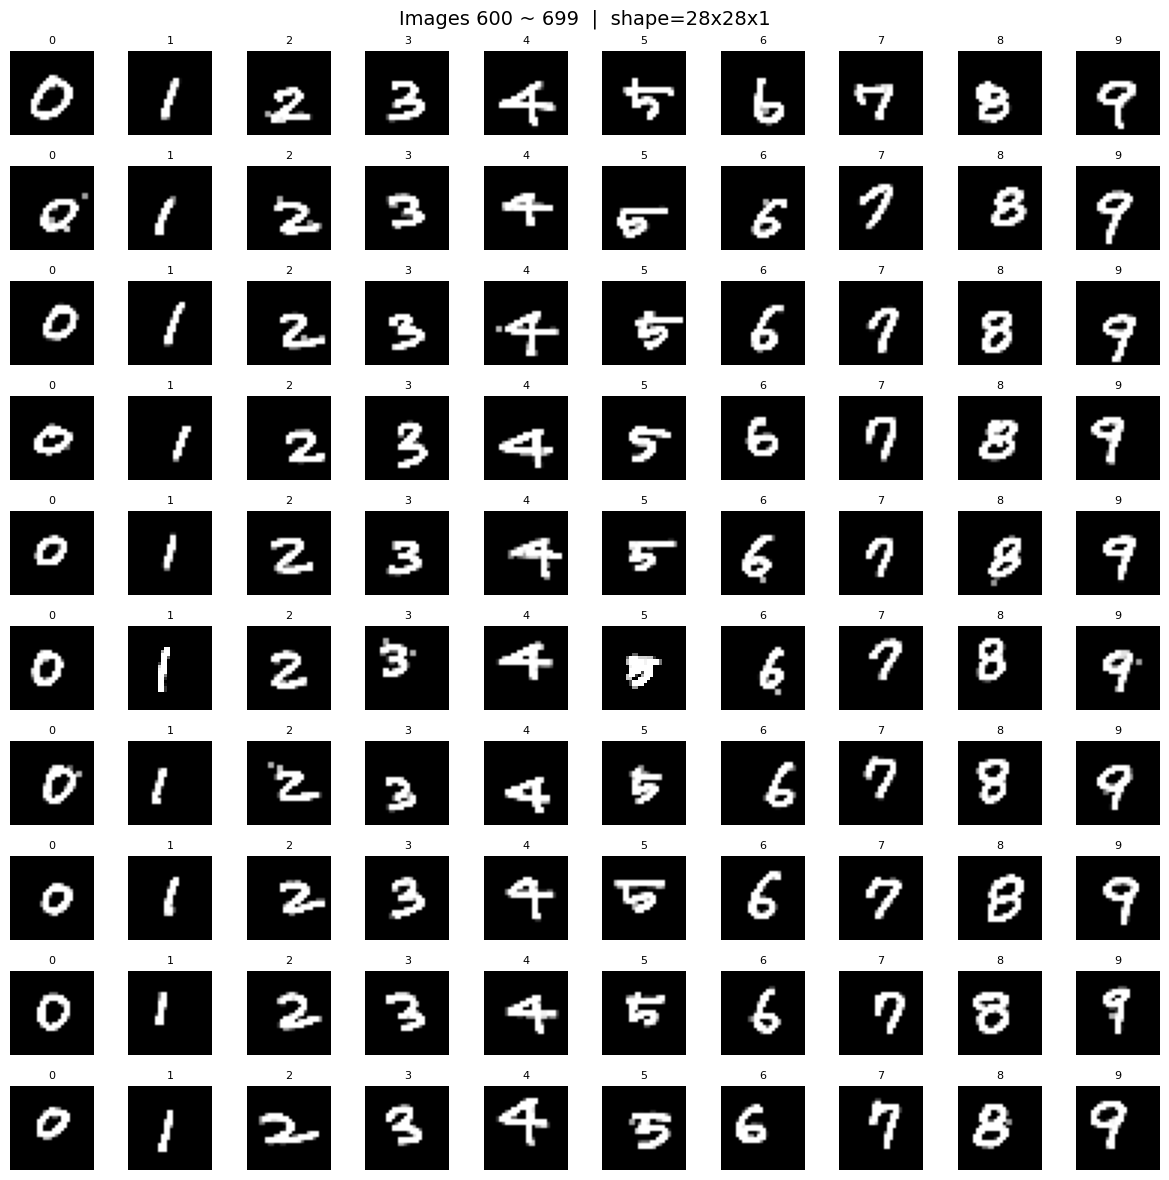

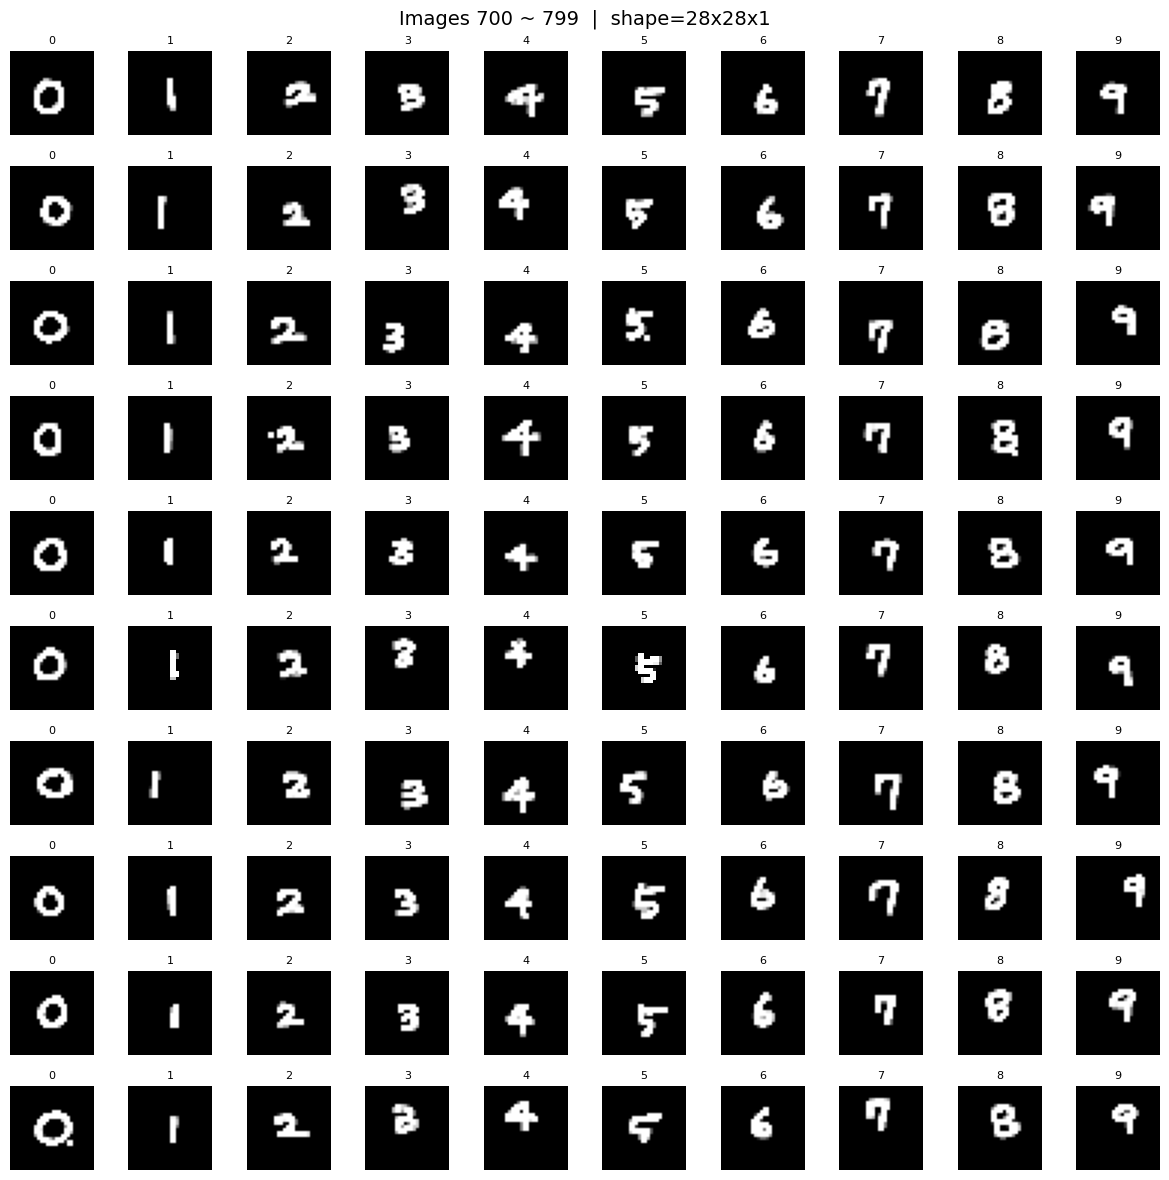

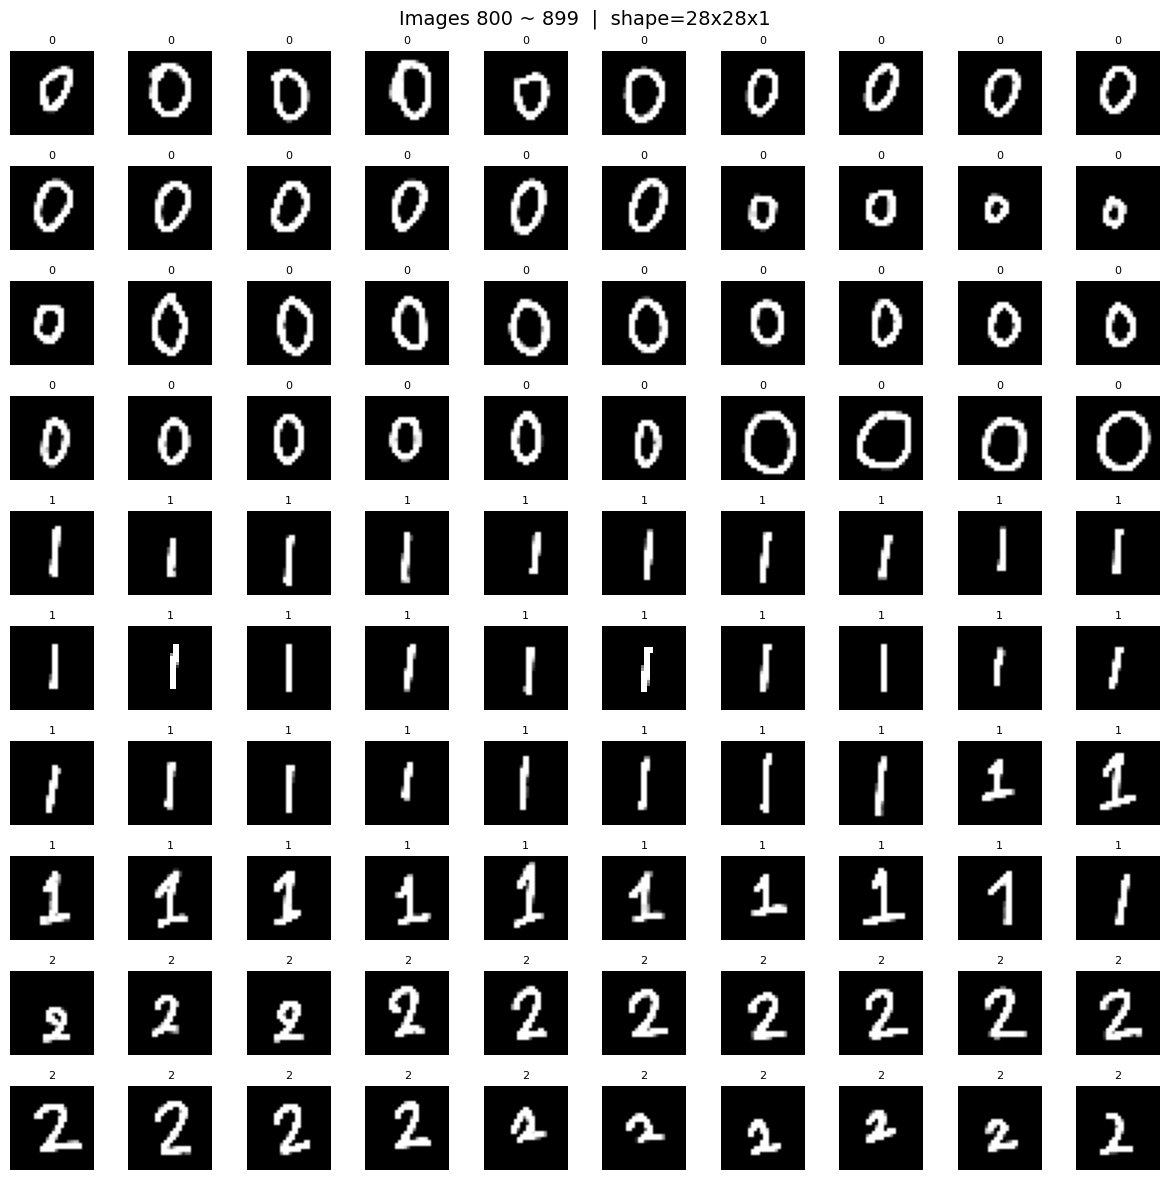

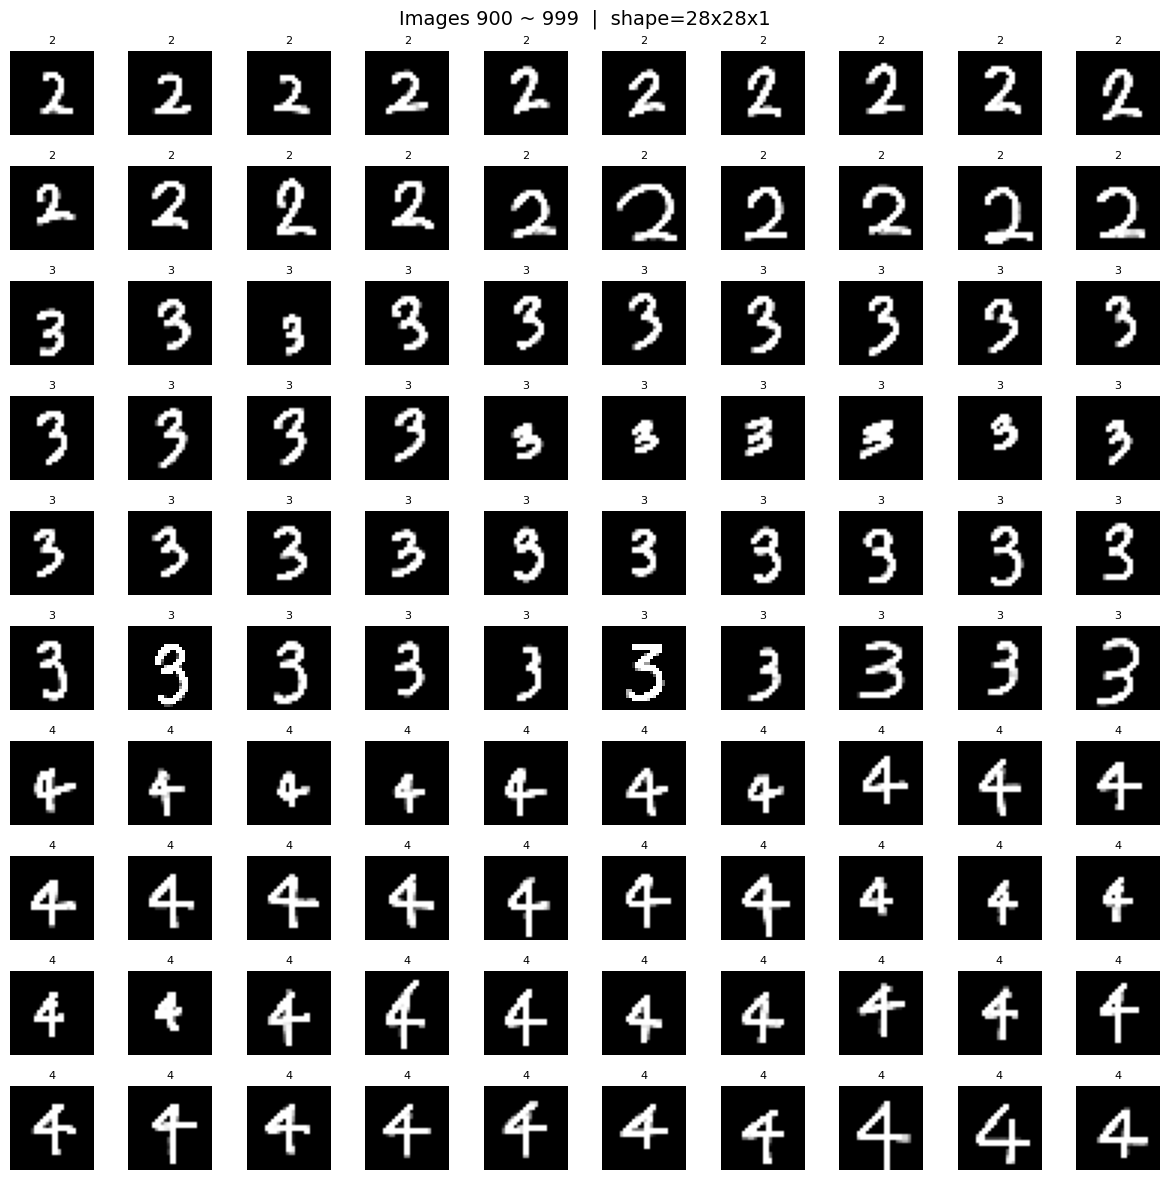

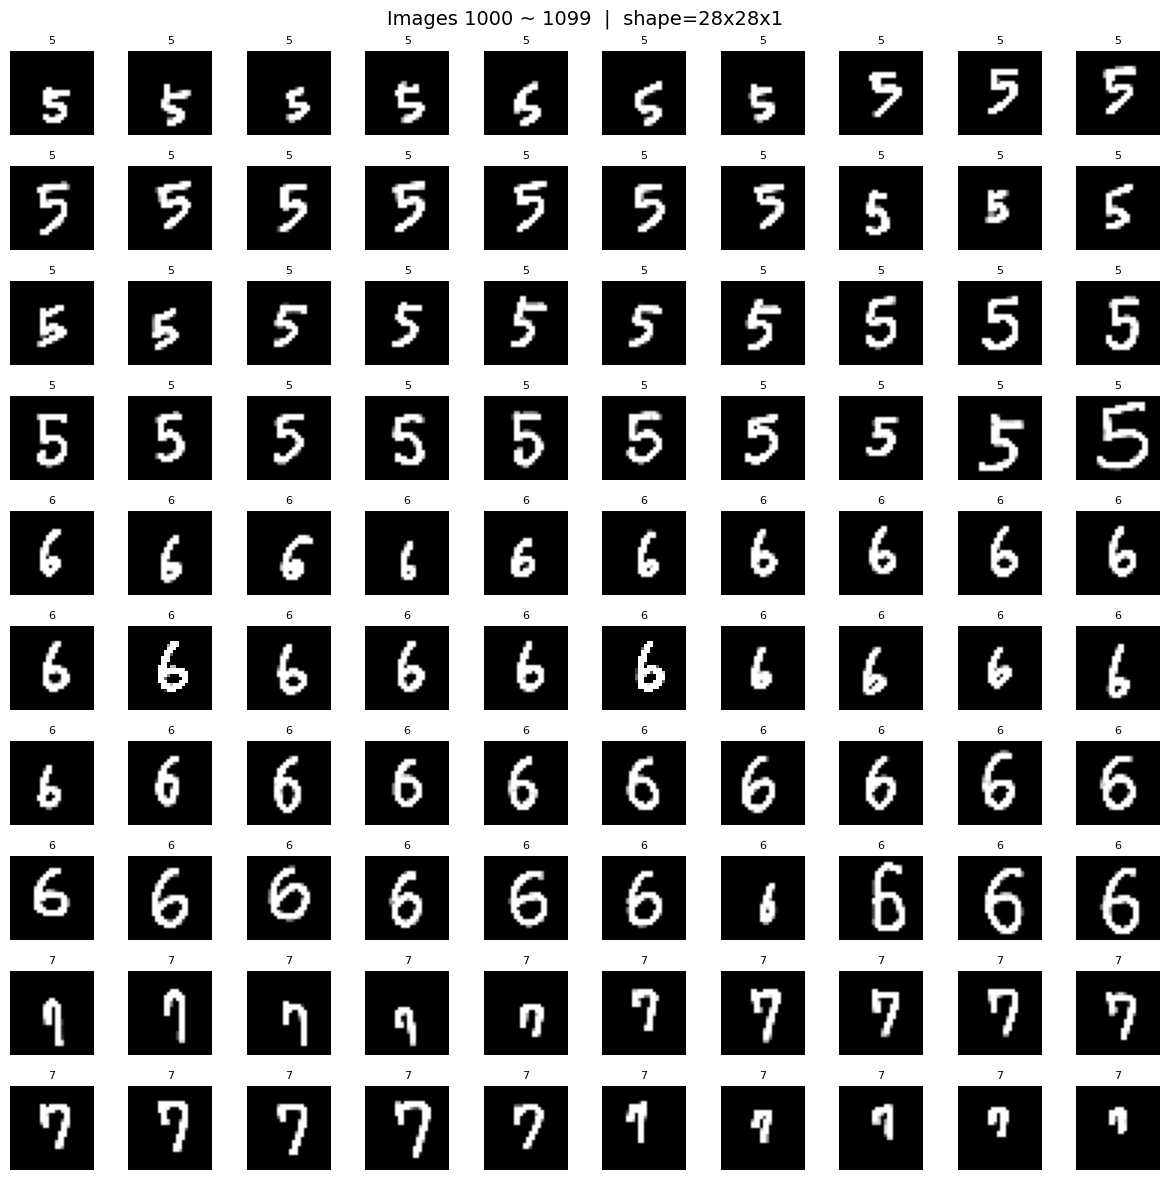

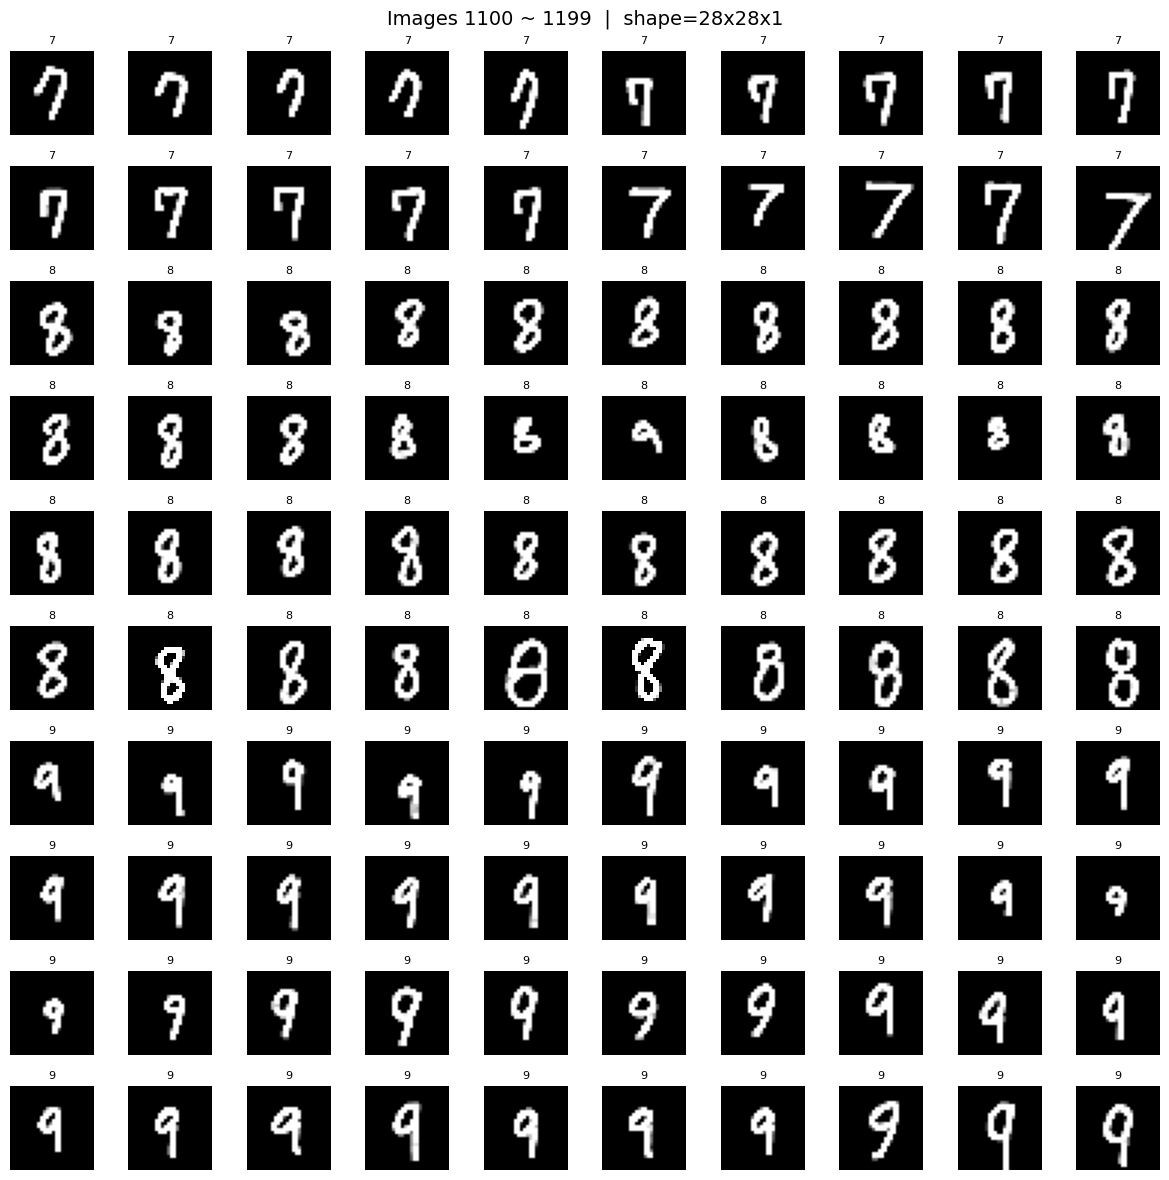

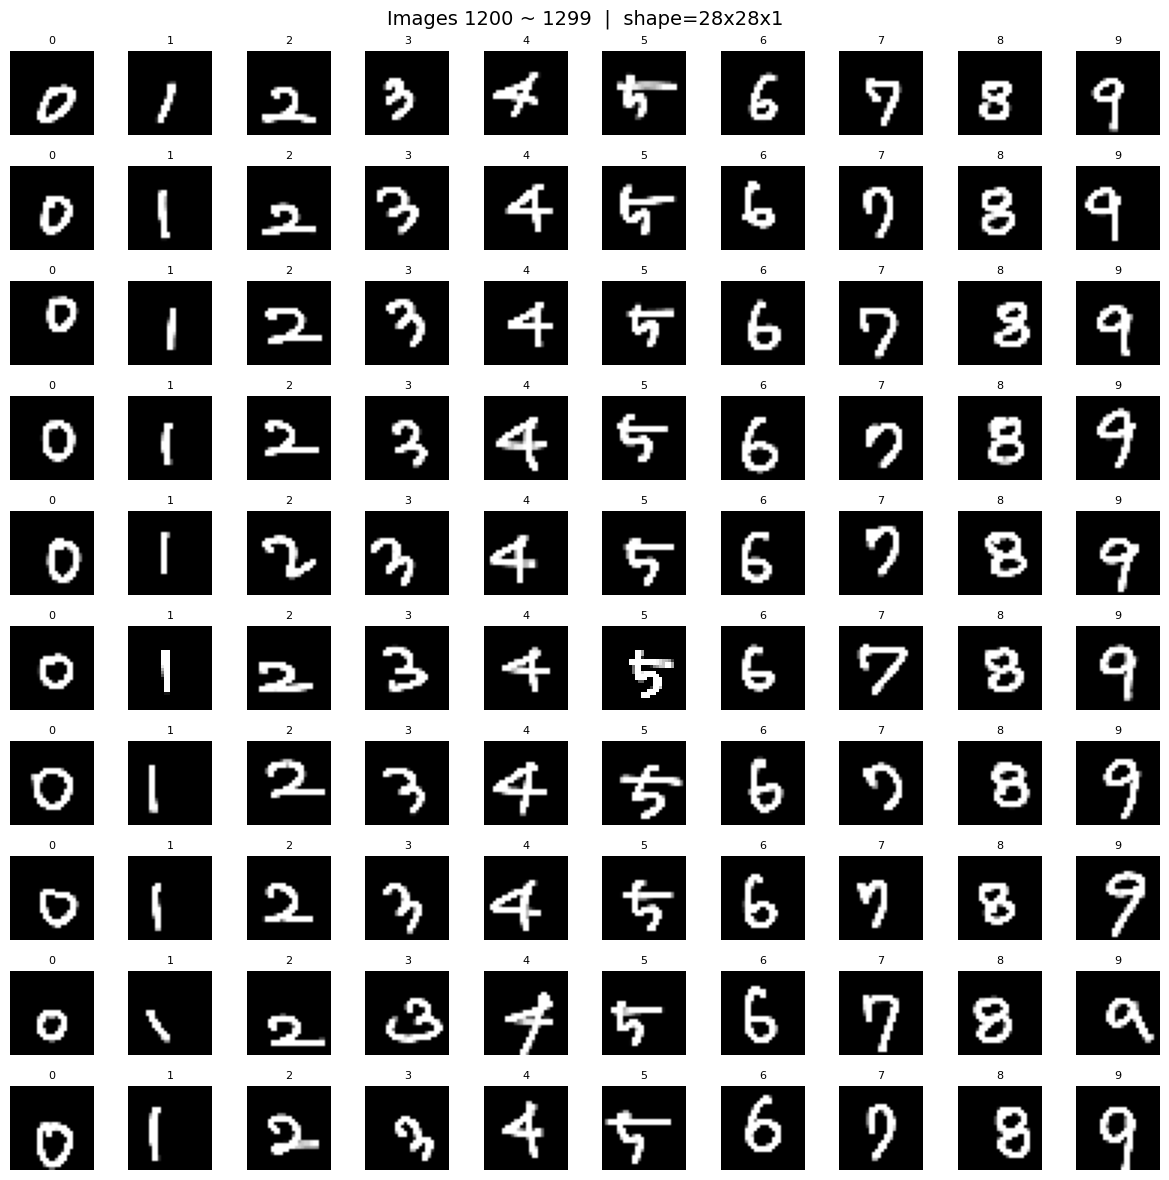

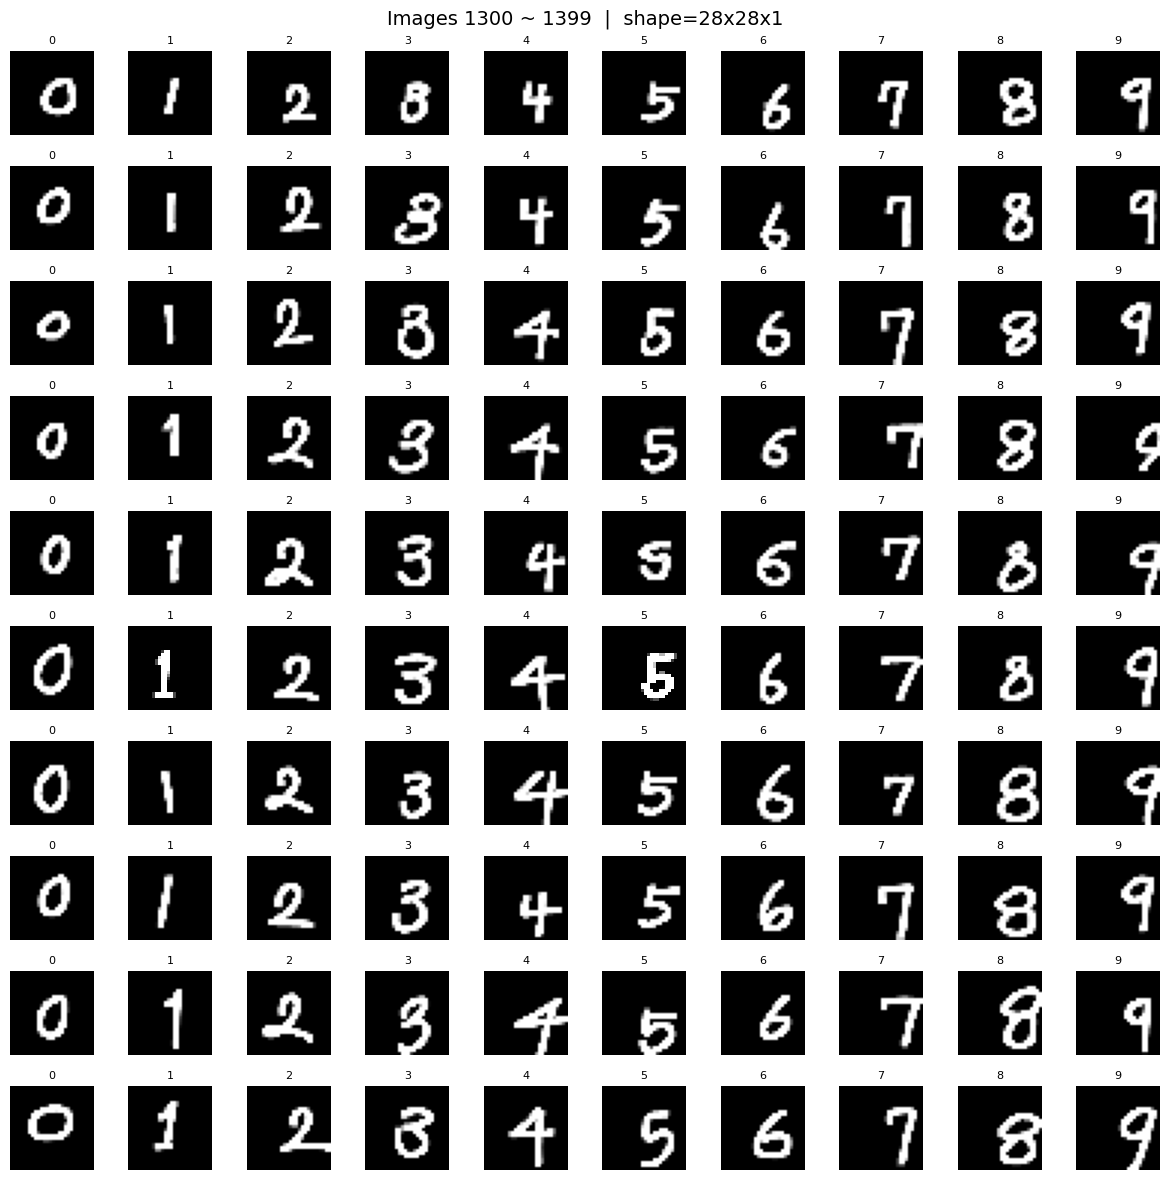

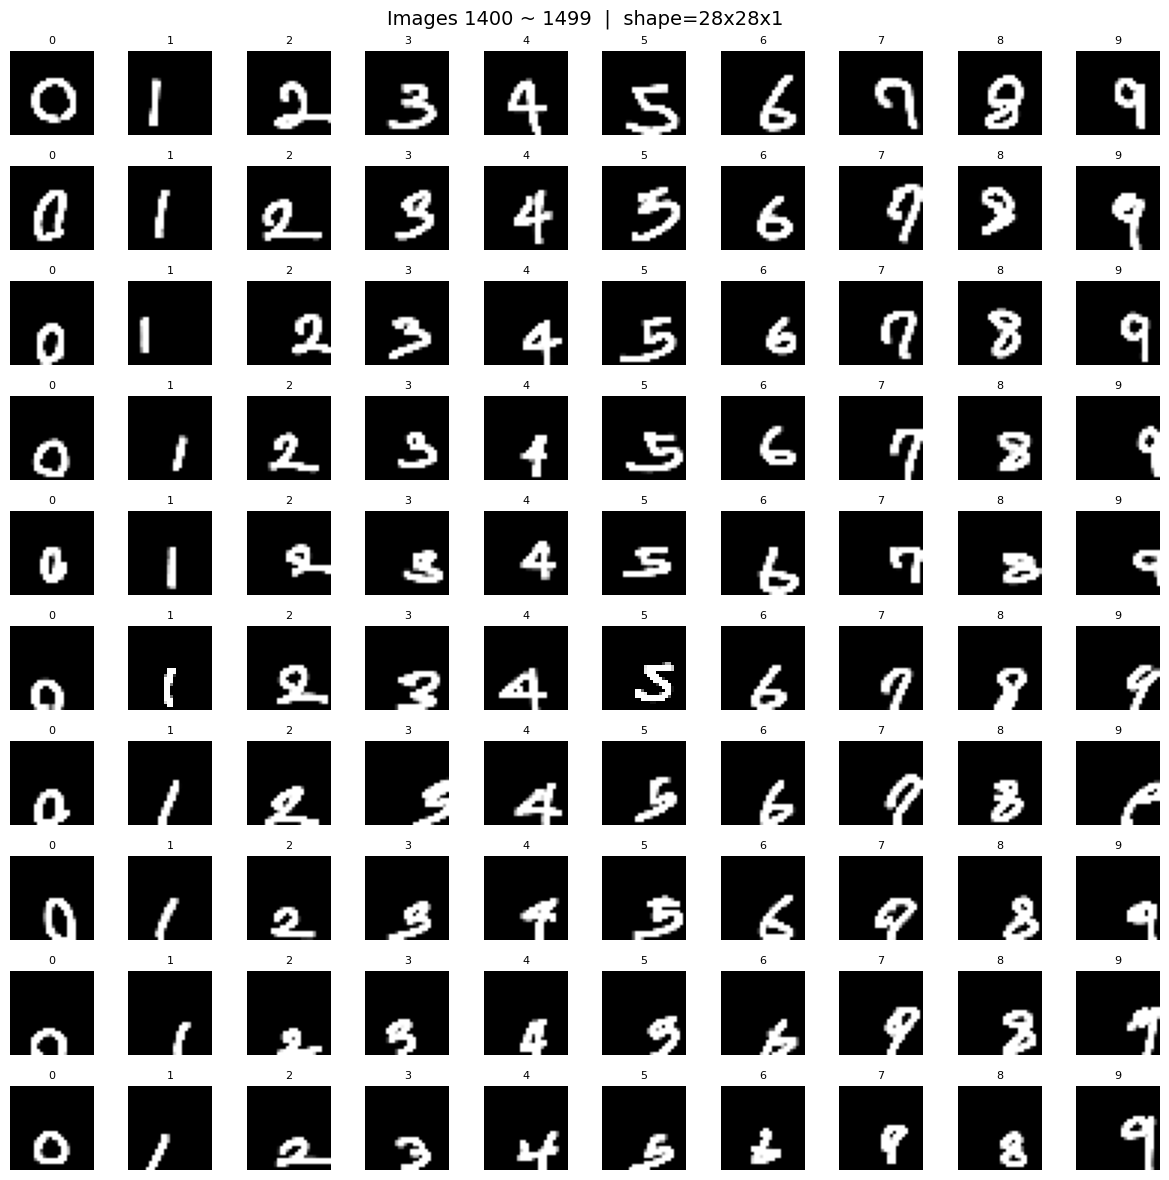

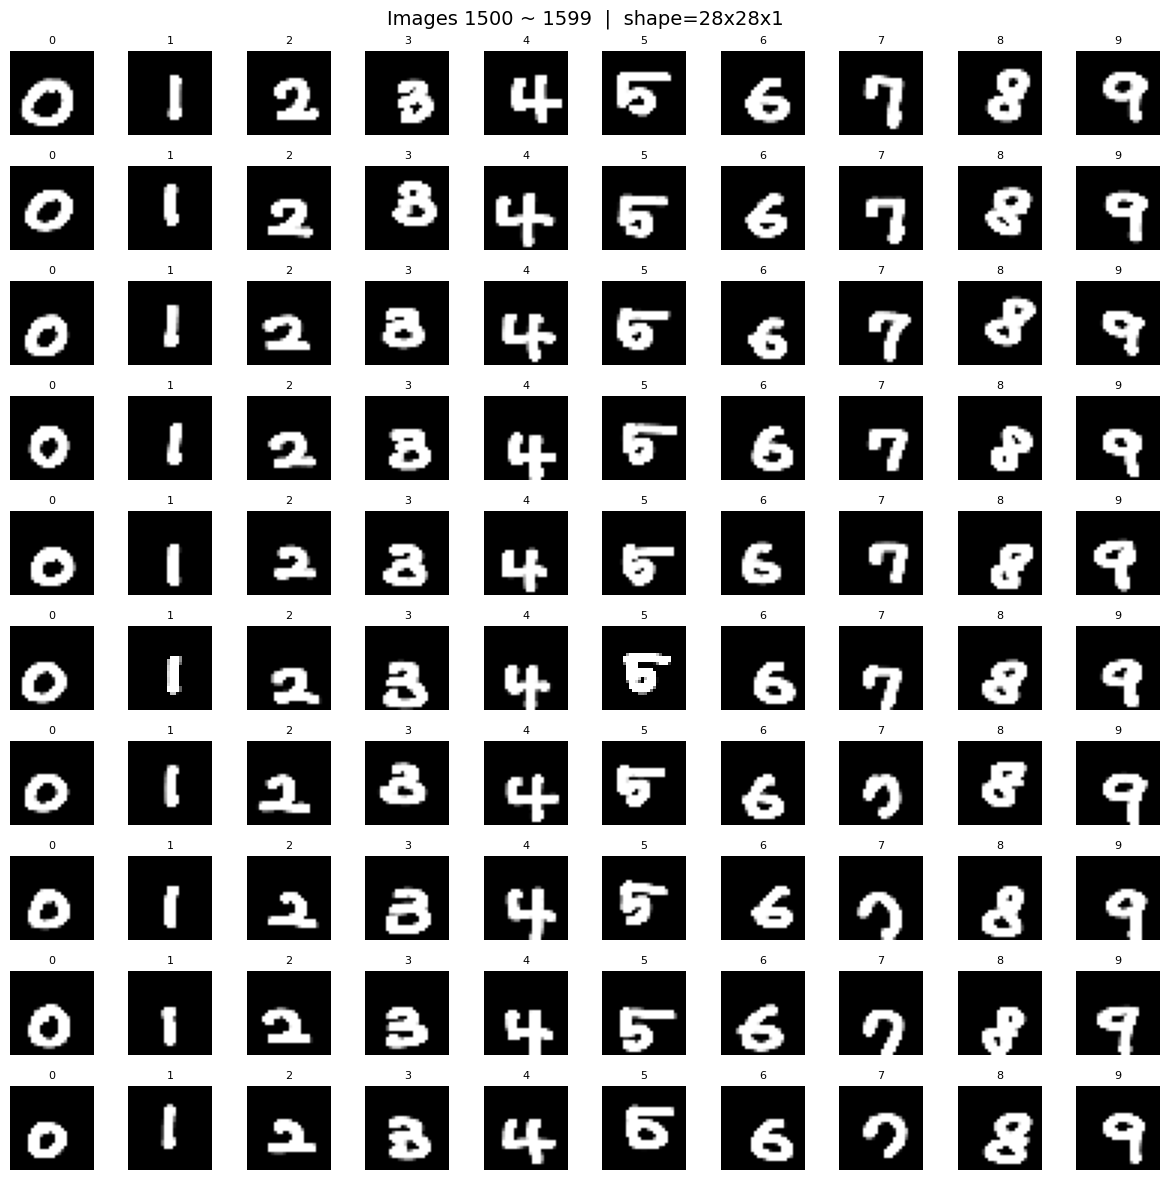

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# npz 불러오기 (경로만 맞춰줘)
data = np.load("new3.npz")
# 키 자동 인식
X = data['img'] if 'img' in data.files else data['X']
y = data['label'] if 'label' in data.files else data['y']

print("X shape:", X.shape)  # (N, D) 또는 (N,H,W[,C])

def infer_shape_from_flat(D):
    """
    D: 2D 벡터의 길이(X.shape[1]).
    반환: (H, W, C)
    - 그레이스케일 정사각형, RGB 정사각형 자동 추정
    """
    # grayscale 정사각형
    s = int(math.isqrt(D))
    if s * s == D:
        return s, s, 1
    # RGB 정사각형 (D = 3*s*s)
    if D % 3 == 0:
        D3 = D // 3
        s3 = int(math.isqrt(D3))
        if s3 * s3 == D3:
            return s3, s3, 3
    # 흔한 케이스 직접 체크 (예: 380*380)
    for cand in [380, 224, 128, 96, 64, 32]:
        if cand * cand == D:
            return cand, cand, 1
        if 3 * cand * cand == D:
            return cand, cand, 3
    raise ValueError(f"플랫 벡터 길이 {D}에서 (H,W[,C]) 추정 실패")

# X가 평탄화되어 있으면 복원 정보 추정
if X.ndim == 2:
    H, W, C = infer_shape_from_flat(X.shape[1])
    print(f"Inferred shape: {H}x{W}x{C}")
    if C == 1:
        def get_img(n):  # (H,W)
            return X[n].reshape(H, W)
    else:
        def get_img(n):  # (H,W,3)
            return X[n].reshape(H, W, C)
elif X.ndim == 3:
    H, W = X.shape[1], X.shape[2]
    C = 1
    def get_img(n): return X[n]
else:  # (N,H,W,C)
    H, W, C = X.shape[1], X.shape[2], X.shape[3]
    def get_img(n): return X[n]

# 픽셀 스케일 정규화(필요 시)
Xmax = X.max()
if Xmax > 1.5:
    X = X.astype(np.float32) / 255.0

# 10x10씩 전체 표시 (한 번에 100장)
num_r, num_c = 10, 10
batch = num_r * num_c
N = X.shape[0]

for start in range(0, N, batch):
    end = min(start + batch, N)
    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(range(start, end)):
        plt.subplot(num_r, num_c, i+1)
        img = get_img(idx)
        if C == 1:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(img)
        plt.axis('off')
        plt.title(str(y[idx]), fontsize=8)
    plt.suptitle(f"Images {start} ~ {end-1}  |  shape={H}x{W}x{C}", fontsize=14)
    plt.tight_layout()
    plt.show()


3. 앞에서 결정된 파라미터를 입력하여 각각의 모델 학습 진행


Loading model: 02_knn_final_model.joblib
    > 모델 로드 성공.
✅ NPZ 데이터 로드 중: custom_MNIST2.npz
    > 데이터 정규화 완료.
    > 데이터 로드 성공. 로드된 배열 형태(Shape): (11687, 28, 28)
    > 이미지 차원: 28x28으로 예상.
Performing prediction and calculating accuracy...
---------------------------------
✅ Test Accuracy: 0.1443
Total samples: 11687
---------------------------------

✨ 상위 100개 샘플 시각화 중...


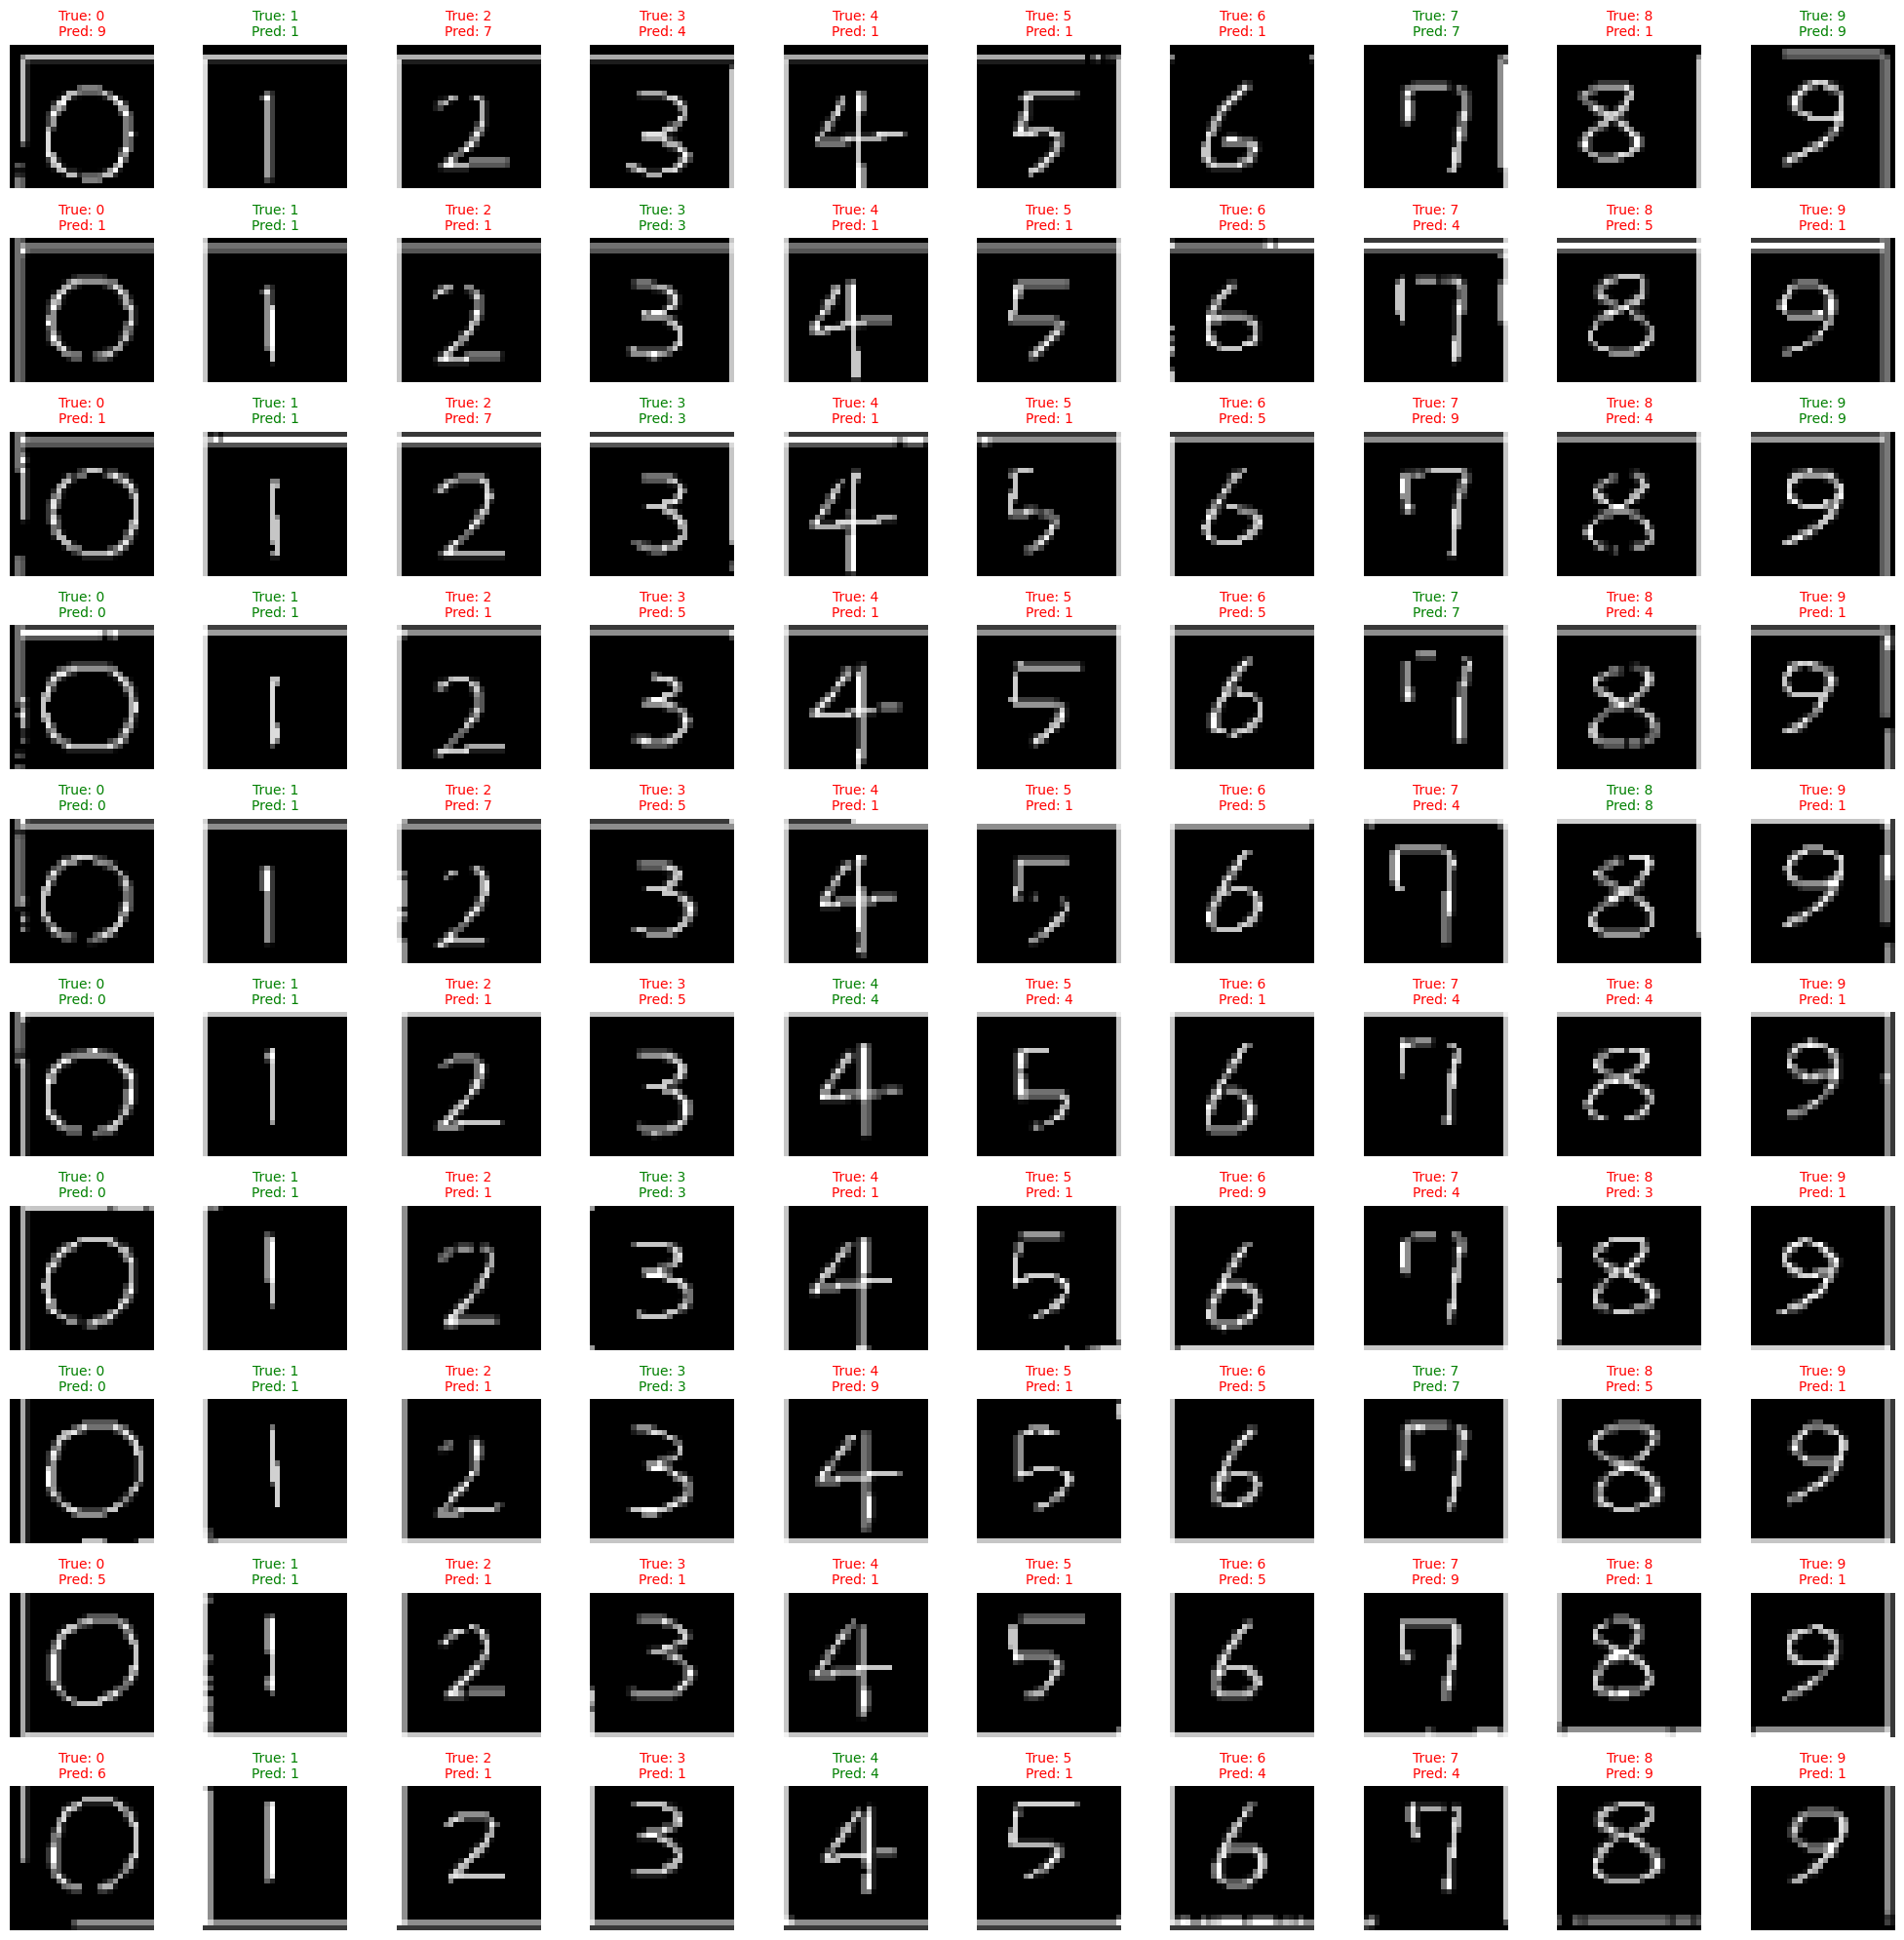

In [ ]:
import numpy as np
import joblib
import os
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 설정 ---
MODEL_FILENAME = "02_knn_final_model.joblib"
DATA_FILEPATH = "custom_MNIST2.npz"
DATA_KEY_X = 'images'
DATA_KEY_Y = 'labels'

# --- 1. Joblib 모델 불러오기 ---
print(f"Loading model: {MODEL_FILENAME}")
try:
    loaded_model = joblib.load(MODEL_FILENAME)
    print("    > 모델 로드 성공.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    # 파일이 없는 경우 코드가 더 진행되지 않도록 exit() 유지
    exit()

# --- 2. NPZ 파일에서 테스트 데이터 로드 ---
print(f"✅ NPZ 데이터 로드 중: {DATA_FILEPATH}")
X_test_3d = None
y_true = None

try:
    npz_file = np.load(DATA_FILEPATH)

    # 데이터 할당 (3차원 또는 2차원 모두 로드)
    X_test_3d = npz_file[DATA_KEY_X]
    y_true = npz_file[DATA_KEY_Y]

    # 🟢 데이터 정규화 (0-1 범위)
    if X_test_3d.max() > 1.0:
        X_test_3d = X_test_3d / 255.0
        print("    > 데이터 정규화 완료.")

    print(f"    > 데이터 로드 성공. 로드된 배열 형태(Shape): {X_test_3d.shape}")

    # 이미지 차원 확인 (3차원 데이터에서 H, W를 추출)
    if X_test_3d.ndim >= 3:
        N_samples, H, W = X_test_3d.shape[:3]
        image_dim = H
        print(f"    > 이미지 차원: {image_dim}x{image_dim}으로 예상.")
    else:
        # 데이터가 이미 2차원 (N, D) 형태라면 평탄화할 필요 없음
        N_samples, D_flat = X_test_3d.shape
        image_dim = int(np.sqrt(D_flat))
        print(f"    > 데이터 형태가 이미 평탄화된 것으로 예상됨 ({image_dim}x{image_dim}).")
        X_test_3d = X_test_3d.reshape(-1, image_dim, image_dim) # 시각화를 위해 3D로 복원

except KeyError:
    print(f"❌ Error: Missing keys in NPZ file. (keys should be '{DATA_KEY_X}', '{DATA_KEY_Y}')")
    exit()
except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit()

# 📌 FIX: 예측에 사용할 2차원 데이터 생성
if X_test_3d.ndim >= 3:
    X_test_flat = X_test_3d.reshape(N_samples, -1)
else:
    # 이미 2D라면 그대로 사용 (단, 위 로직에서 X_test_3d는 3D로 복원됨)
    X_test_flat = X_test_3d.reshape(N_samples, -1)


# --- 3. 예측 수행 및 정확도 계산 ---
print("Performing prediction and calculating accuracy...")
y_pred = None
try:
    if X_test_flat is not None and y_true is not None:

        # 📌 FIX: 평탄화된 데이터(X_test_flat)를 모델에 입력
        y_pred = loaded_model.predict(X_test_flat)

        # 정확도 계산
        accuracy = accuracy_score(y_true, y_pred)

        print("---------------------------------")
        print(f"✅ Test Accuracy: {accuracy:.4f}")
        print(f"Total samples: {len(y_true)}")
        print("---------------------------------")
    else:
        print("❌ 오류: X_test 또는 y_true가 NPZ 파일에서 로드되지 않았습니다.")
        exit()

except Exception as e:
    print(f"❌ Error during prediction: {e}")
    exit()

# --- 4. 상위 100개 샘플 시각화 ---
if y_pred is not None and X_test_3d is not None:

    N_SAMPLES_TO_SHOW = 100

    num_samples_to_show = min(N_SAMPLES_TO_SHOW, len(X_test_3d))

    # 3차원 이미지를 사용
    images = X_test_3d[:num_samples_to_show]
    true_labels = y_true[:num_samples_to_show]
    predicted_labels = y_pred[:num_samples_to_show]

    print(f"\n✨ 상위 {num_samples_to_show}개 샘플 시각화 중...")

    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    axes = axes.flatten()

    for i in range(num_samples_to_show):
        axes[i].imshow(images[i], cmap='gray')

        color = 'green' if predicted_labels[i] == true_labels[i] else 'red'

        axes[i].set_title(
            f"True: {true_labels[i]}\nPred: {predicted_labels[i]}",
            color=color,
            fontsize=10
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Loading model: 02_knn_final_model.joblib
    > 모델 로드 성공.

✅ NPZ 데이터 로드 중: custom_MNIST2.npz
    > 로드 성공: X=(11687, 28, 28), y=(11687,) (이미지 28x28)
    > 예측/정확도 계산 중...
---------------------------------
[custom_MNIST2.npz] Test Accuracy: 0.1443
[custom_MNIST2.npz] Total samples: 11687
---------------------------------


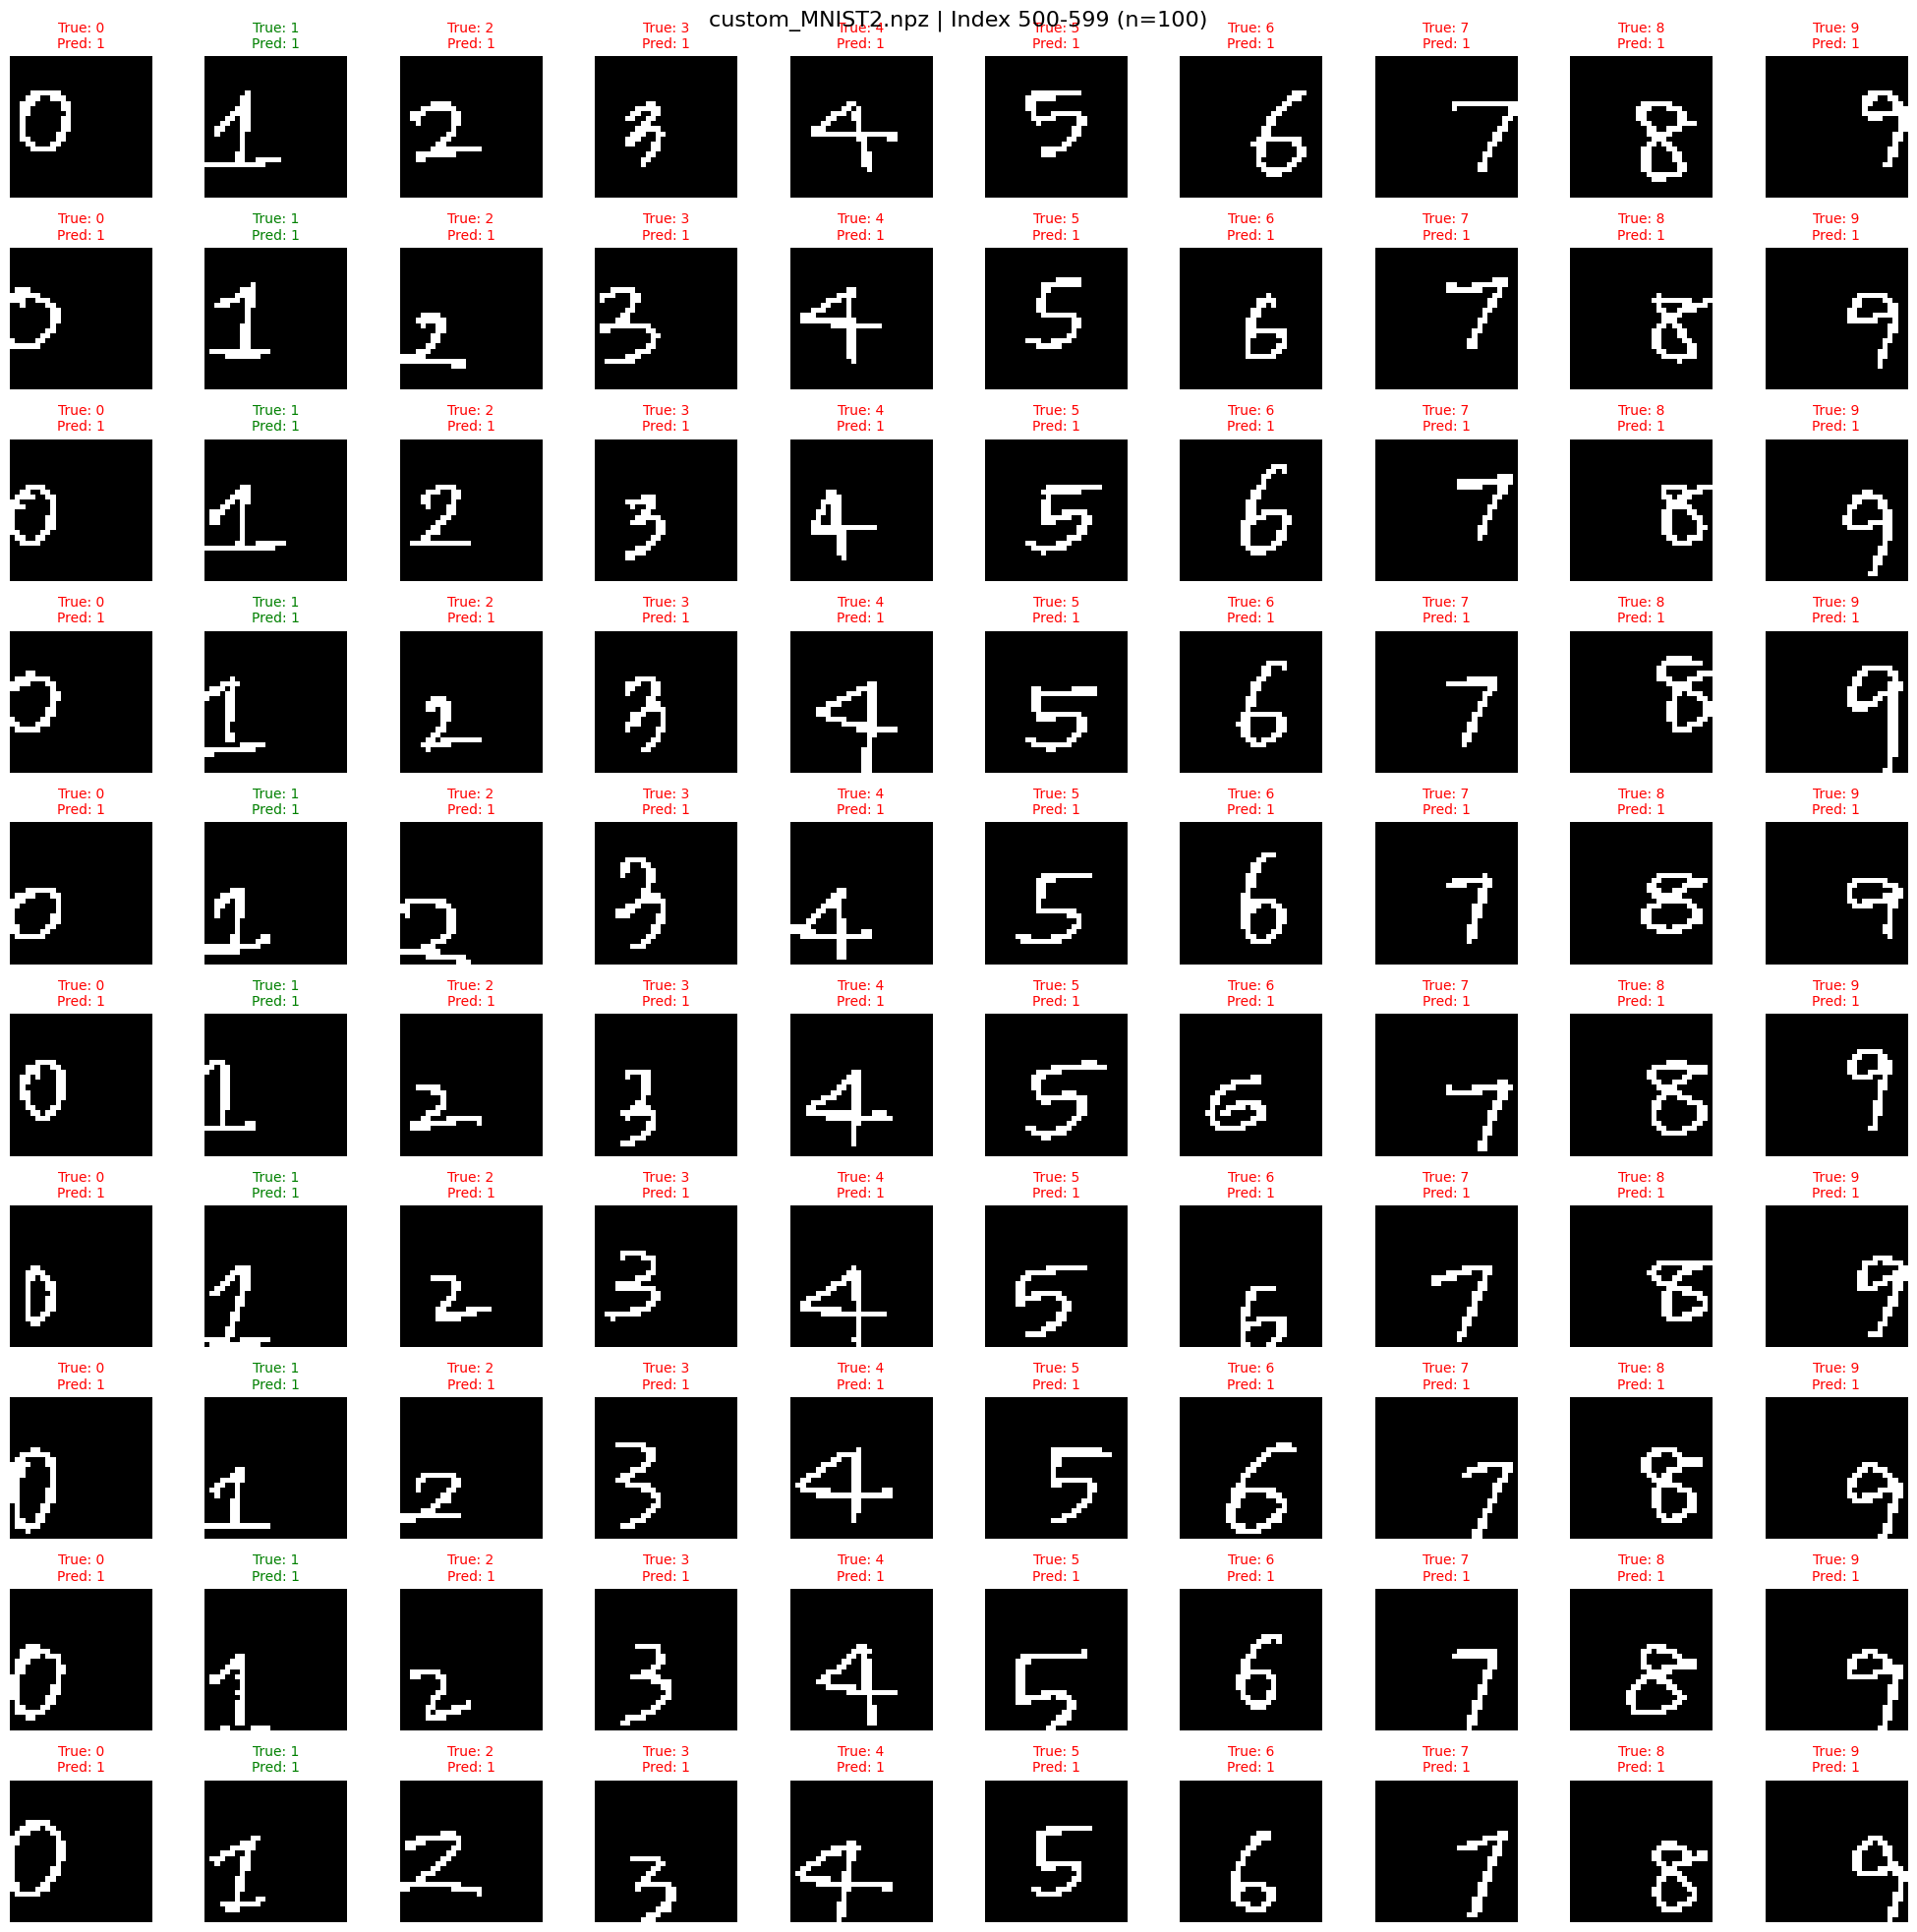


✅ NPZ 데이터 로드 중: final_center.npz
    > 로드 성공: X=(11687, 28, 28), y=(11687,) (이미지 28x28)
    > 예측/정확도 계산 중...
---------------------------------
[final_center.npz] Test Accuracy: 0.3216
[final_center.npz] Total samples: 11687
---------------------------------


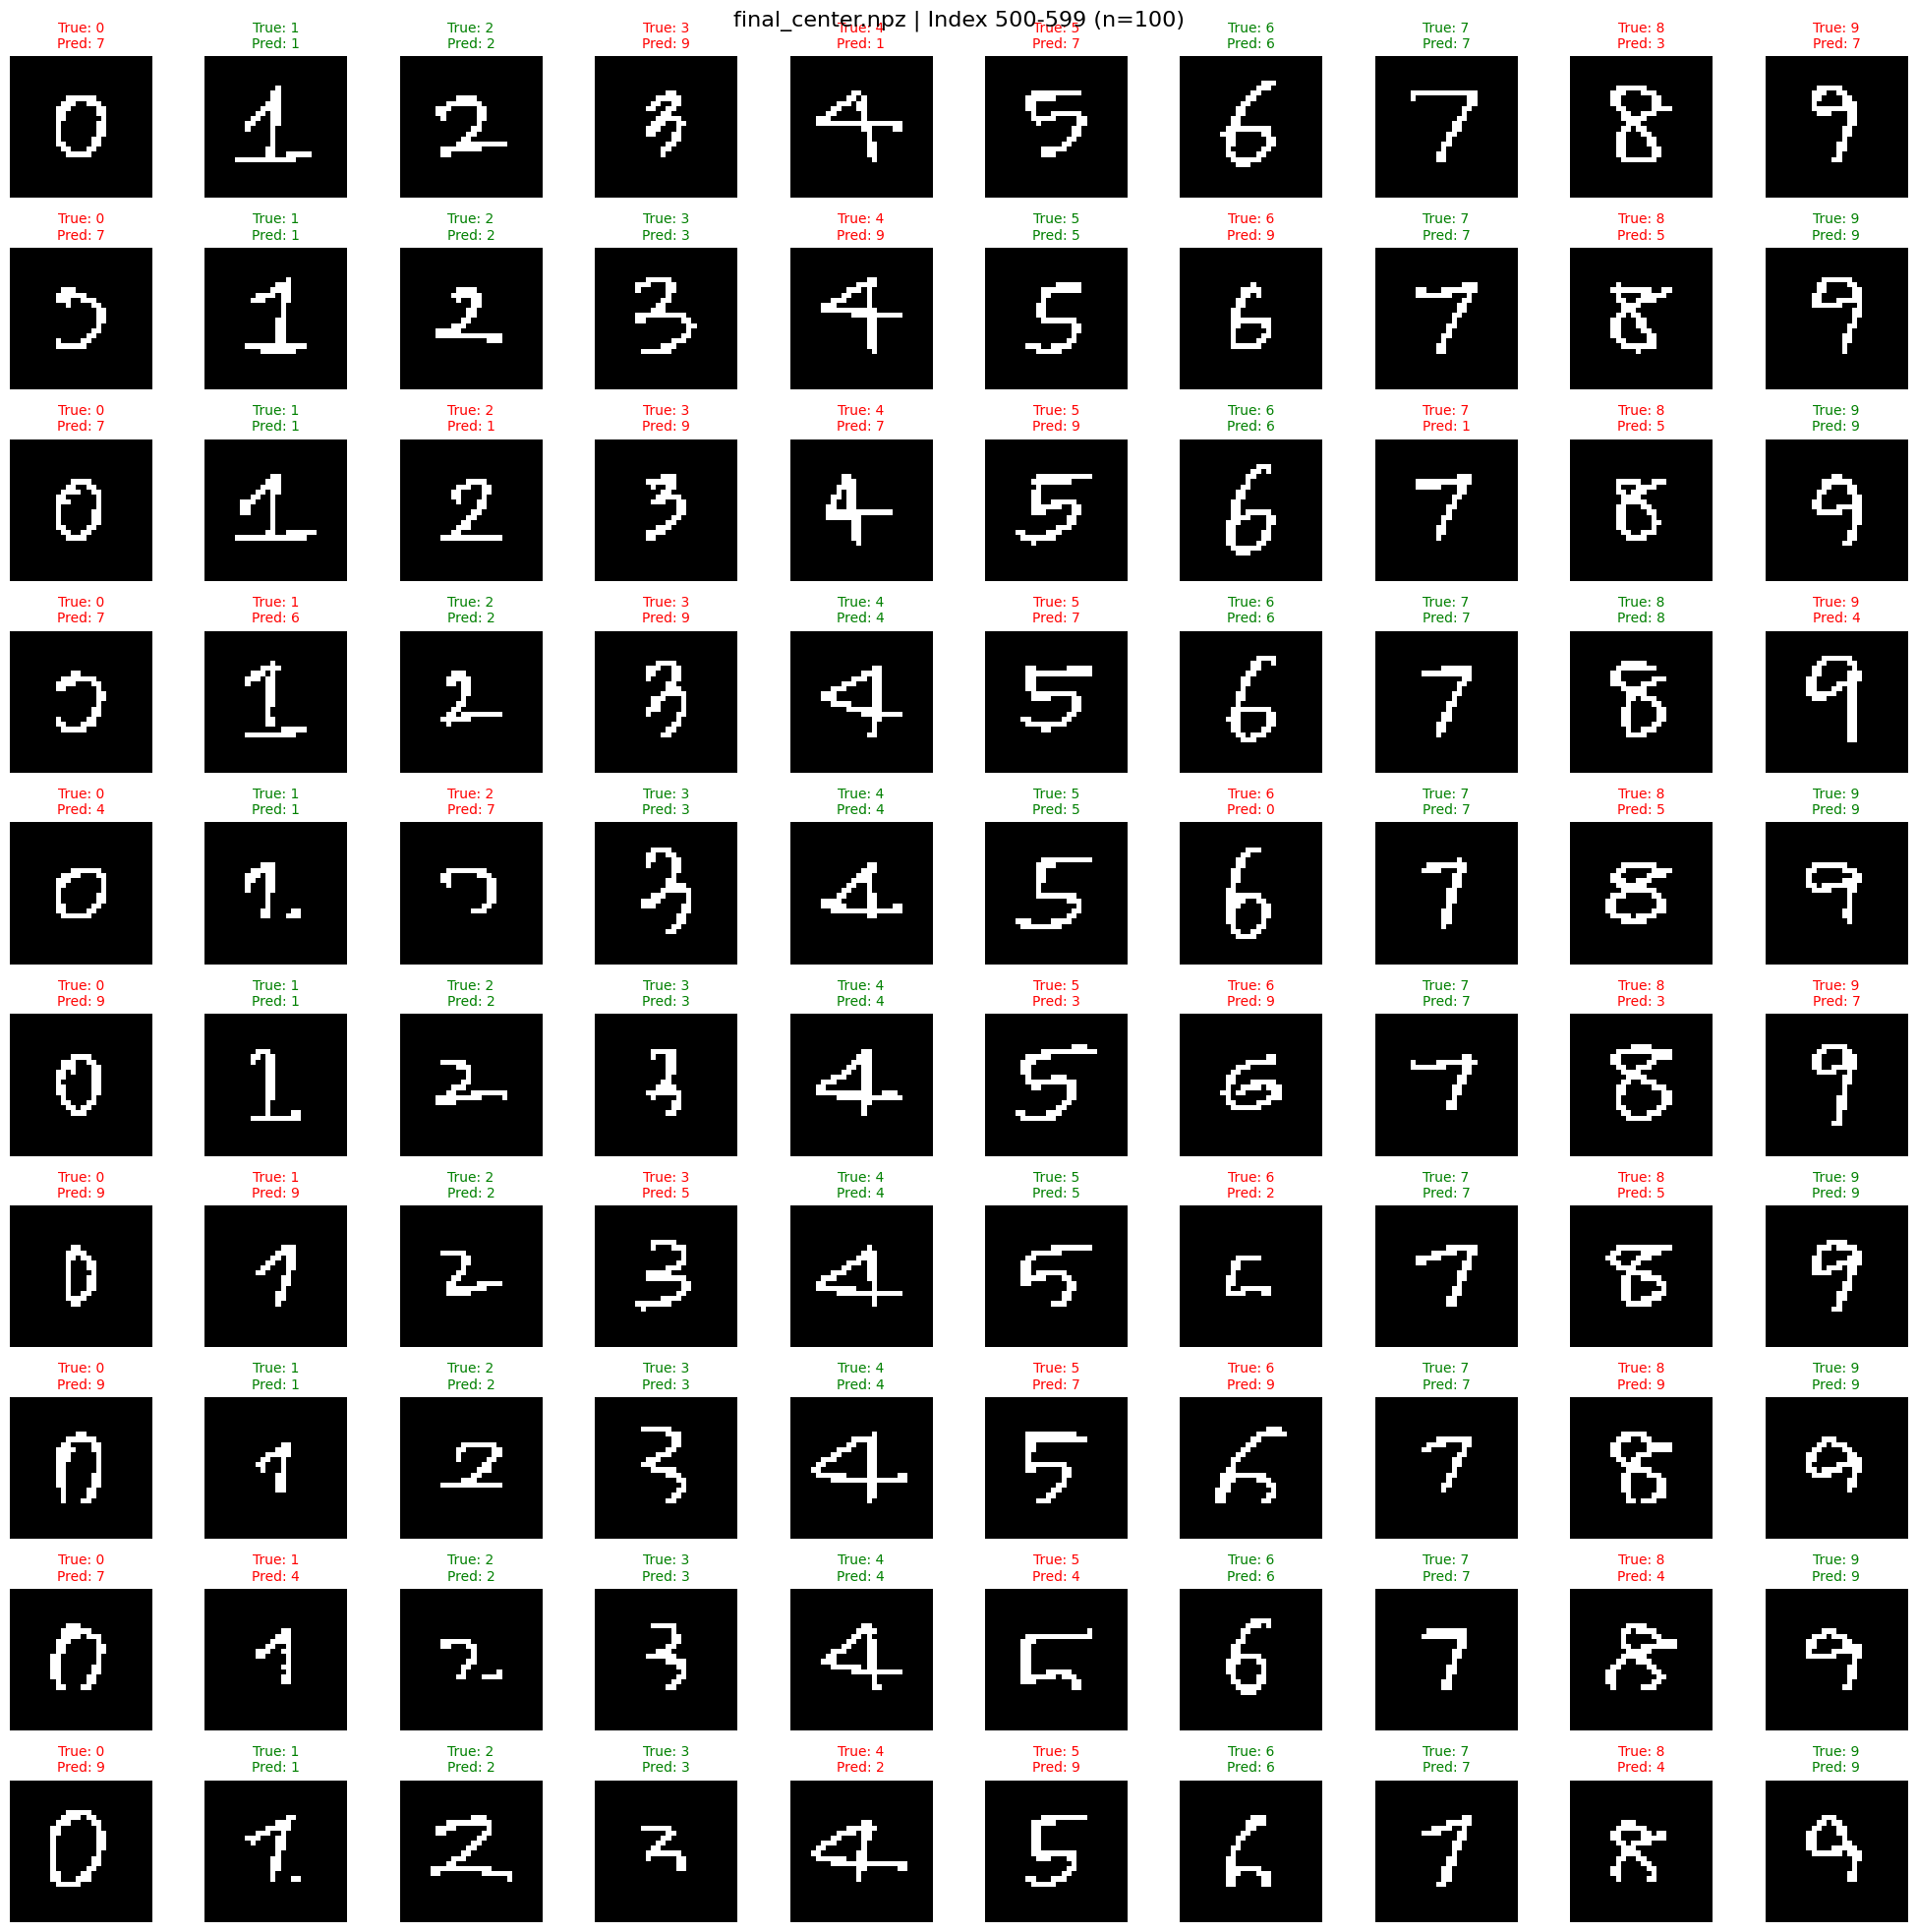

In [ ]:
import numpy as np
import joblib
import os
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -----------------------------
# 설정
# -----------------------------
MODEL_FILENAME = "02_knn_final_model.joblib"
DATASETS = [
    "custom_MNIST2.npz",  # 1번 데이터셋
    "final_center.npz",  # 2번 데이터셋
]

DATA_KEYS_PRIMARY = ("images", "labels")  # 선호 키
DATA_KEYS_FALLBACK = ("X", "y")           # 대체 키

SHOW_START, SHOW_END = 500, 599  # 시각화 구간 (포함)

# -----------------------------
# 유틸 함수
# -----------------------------
def load_npz_dataset(path):
    """
    NPZ 파일에서 (X_3d, y) 반환.
    - 키는 ('images','labels') 우선, 없으면 ('X','y')
    - X가 2D이면 3D로 복원해줌 (시각화용)
    - 값은 0~1 정규화 보장
    """
    npz = np.load(path)
    if all(k in npz.files for k in DATA_KEYS_PRIMARY):
        X = npz[DATA_KEYS_PRIMARY[0]]
        y = npz[DATA_KEYS_PRIMARY[1]]
    elif all(k in npz.files for k in DATA_KEYS_FALLBACK):
        X = npz[DATA_KEYS_FALLBACK[0]]
        y = npz[DATA_KEYS_FALLBACK[1]]
    else:
        raise KeyError(f"NPZ keys not found in {path}. Need one of {DATA_KEYS_PRIMARY} or {DATA_KEYS_FALLBACK}.")

    # 정규화
    if X.max() > 1.0:
        X = X.astype(np.float32) / 255.0

    # 3D로 보장
    if X.ndim == 2:  # (N, D)
        N, D = X.shape
        side = int(np.sqrt(D))
        if side * side != D:
            raise ValueError(f"Cannot infer square image from flattened size {D}")
        X_3d = X.reshape(N, side, side)
    elif X.ndim == 3:  # (N, H, W)
        X_3d = X
    else:
        raise ValueError(f"Unsupported X shape {X.shape} in {path}")

    return X_3d, y

def visualize_range(images_3d, y_true, y_pred, start_idx, end_idx, title):
    """
    images_3d, y_true, y_pred에서 [start_idx:end_idx] (포함)만 시각화.
    """
    end_idx = min(end_idx, len(images_3d)-1)
    if start_idx > end_idx:
        print(f"[{title}] 시각화 범위가 데이터 길이보다 큽니다. (총 {len(images_3d)}개)")
        return

    sel_imgs = images_3d[start_idx:end_idx+1]
    sel_true = y_true[start_idx:end_idx+1]
    sel_pred = y_pred[start_idx:end_idx+1]
    n = len(sel_imgs)

    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(20, 20))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(sel_imgs[i], cmap='gray')
        color = 'green' if sel_pred[i] == sel_true[i] else 'red'
        axes[i].set_title(f"True: {sel_true[i]}\nPred: {sel_pred[i]}", color=color, fontsize=10)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{title} | Index {start_idx}-{end_idx} (n={n})", fontsize=16)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 1) 모델 로드
# -----------------------------
print(f"Loading model: {MODEL_FILENAME}")
try:
    model = joblib.load(MODEL_FILENAME)
    print("    > 모델 로드 성공.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise SystemExit

# -----------------------------
# 2) 각 NPZ에 대해 예측/정확도/시각화
# -----------------------------
for path in DATASETS:
    if not os.path.exists(path):
        print(f"⚠️ {path} 가 존재하지 않습니다. 건너뜁니다.")
        continue

    print(f"\n✅ NPZ 데이터 로드 중: {path}")
    try:
        X_3d, y_true = load_npz_dataset(path)
        N, H, W = X_3d.shape
        print(f"    > 로드 성공: X={X_3d.shape}, y={y_true.shape} (이미지 {H}x{W})")
    except Exception as e:
        print(f"❌ Error loading data from {path}: {e}")
        continue

    # 평탄화
    X_flat = X_3d.reshape(N, -1)

    # 예측 & 정확도
    print("    > 예측/정확도 계산 중...")
    try:
        y_pred = model.predict(X_flat)
        acc = accuracy_score(y_true, y_pred)
        print("---------------------------------")
        print(f"[{os.path.basename(path)}] Test Accuracy: {acc:.4f}")
        print(f"[{os.path.basename(path)}] Total samples: {len(y_true)}")
        print("---------------------------------")
    except Exception as e:
        print(f"❌ Error during prediction for {path}: {e}")
        continue

    # 500~599 구간 시각화
    visualize_range(X_3d, y_true, y_pred, SHOW_START, SHOW_END, title=os.path.basename(path))


Loading model: 06_logreg_halving.joblib
    > 모델 로드 성공.

✅ NPZ 데이터 로드 중: custom_MNIST2.npz
    > 로드 성공: X=(11687, 28, 28), y=(11687,) (이미지 28x28)
    > 예측/정확도 계산 중...
---------------------------------
[custom_MNIST2.npz] Test Accuracy: 0.1212
[custom_MNIST2.npz] Total samples: 11687
---------------------------------


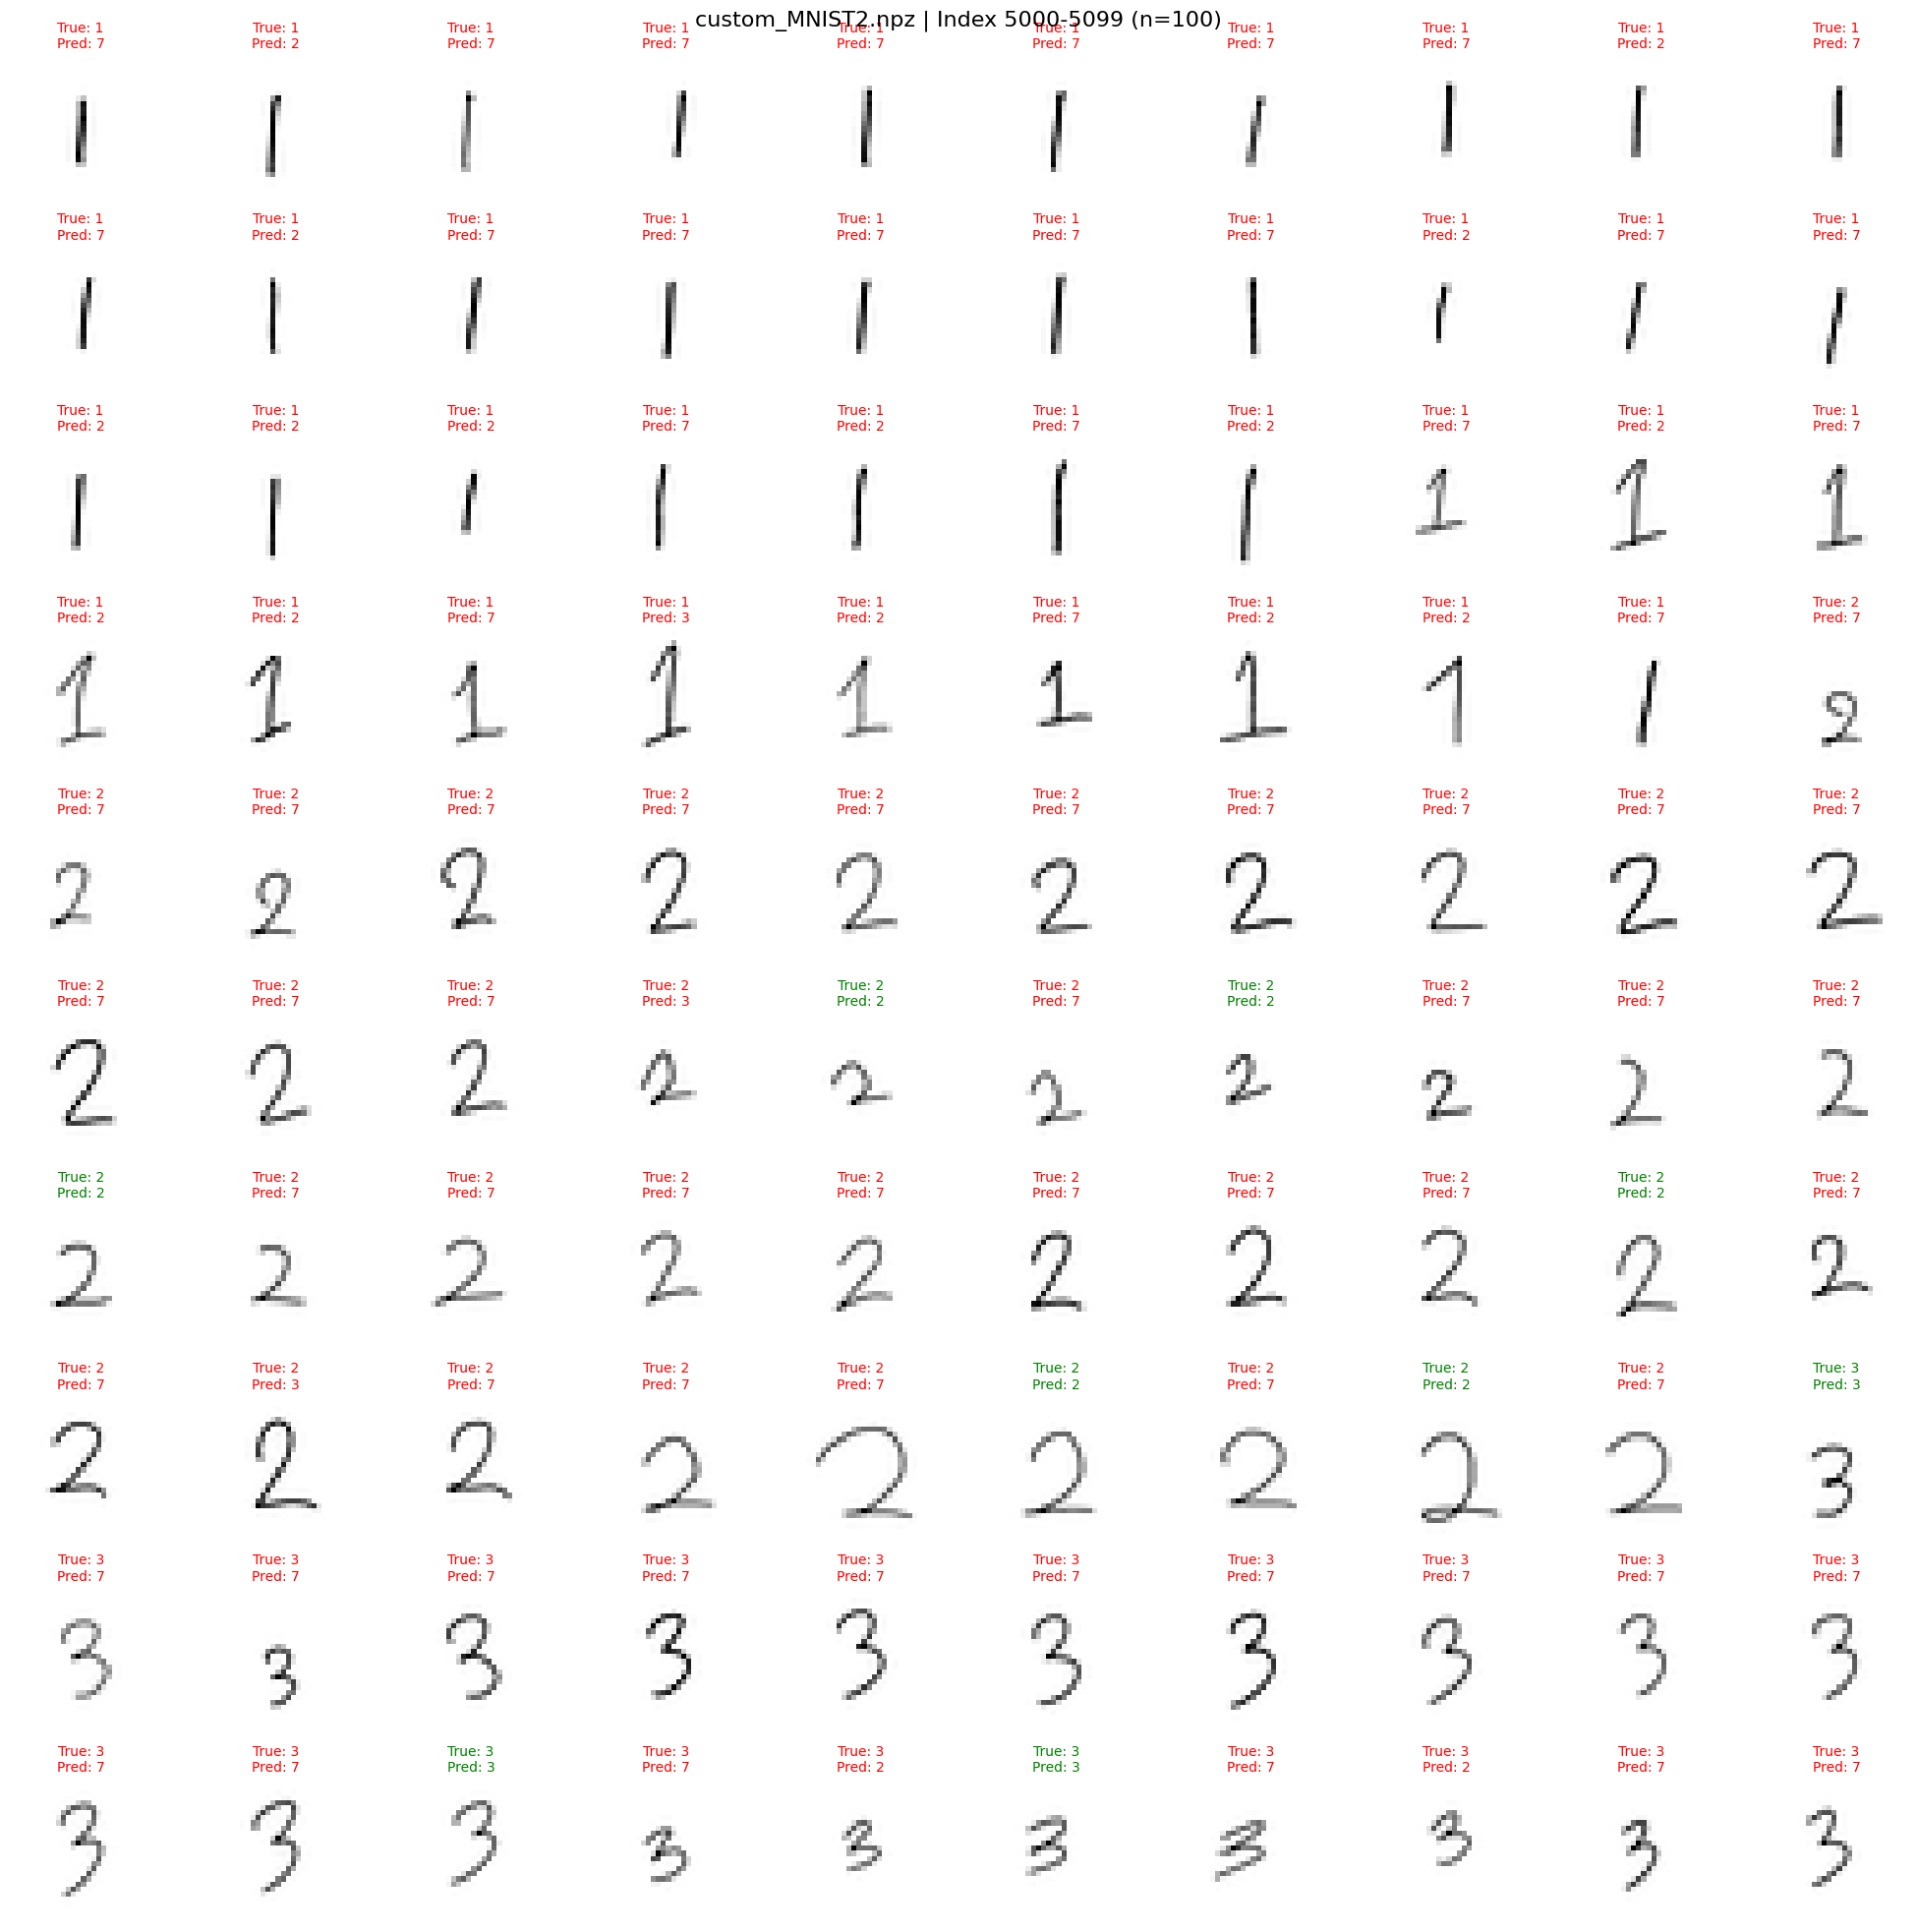


✅ NPZ 데이터 로드 중: final_gu.npz
    > 로드 성공: X=(11687, 28, 28), y=(11687,) (이미지 28x28)
    > 예측/정확도 계산 중...
---------------------------------
[final_gu.npz] Test Accuracy: 0.0997
[final_gu.npz] Total samples: 11687
---------------------------------


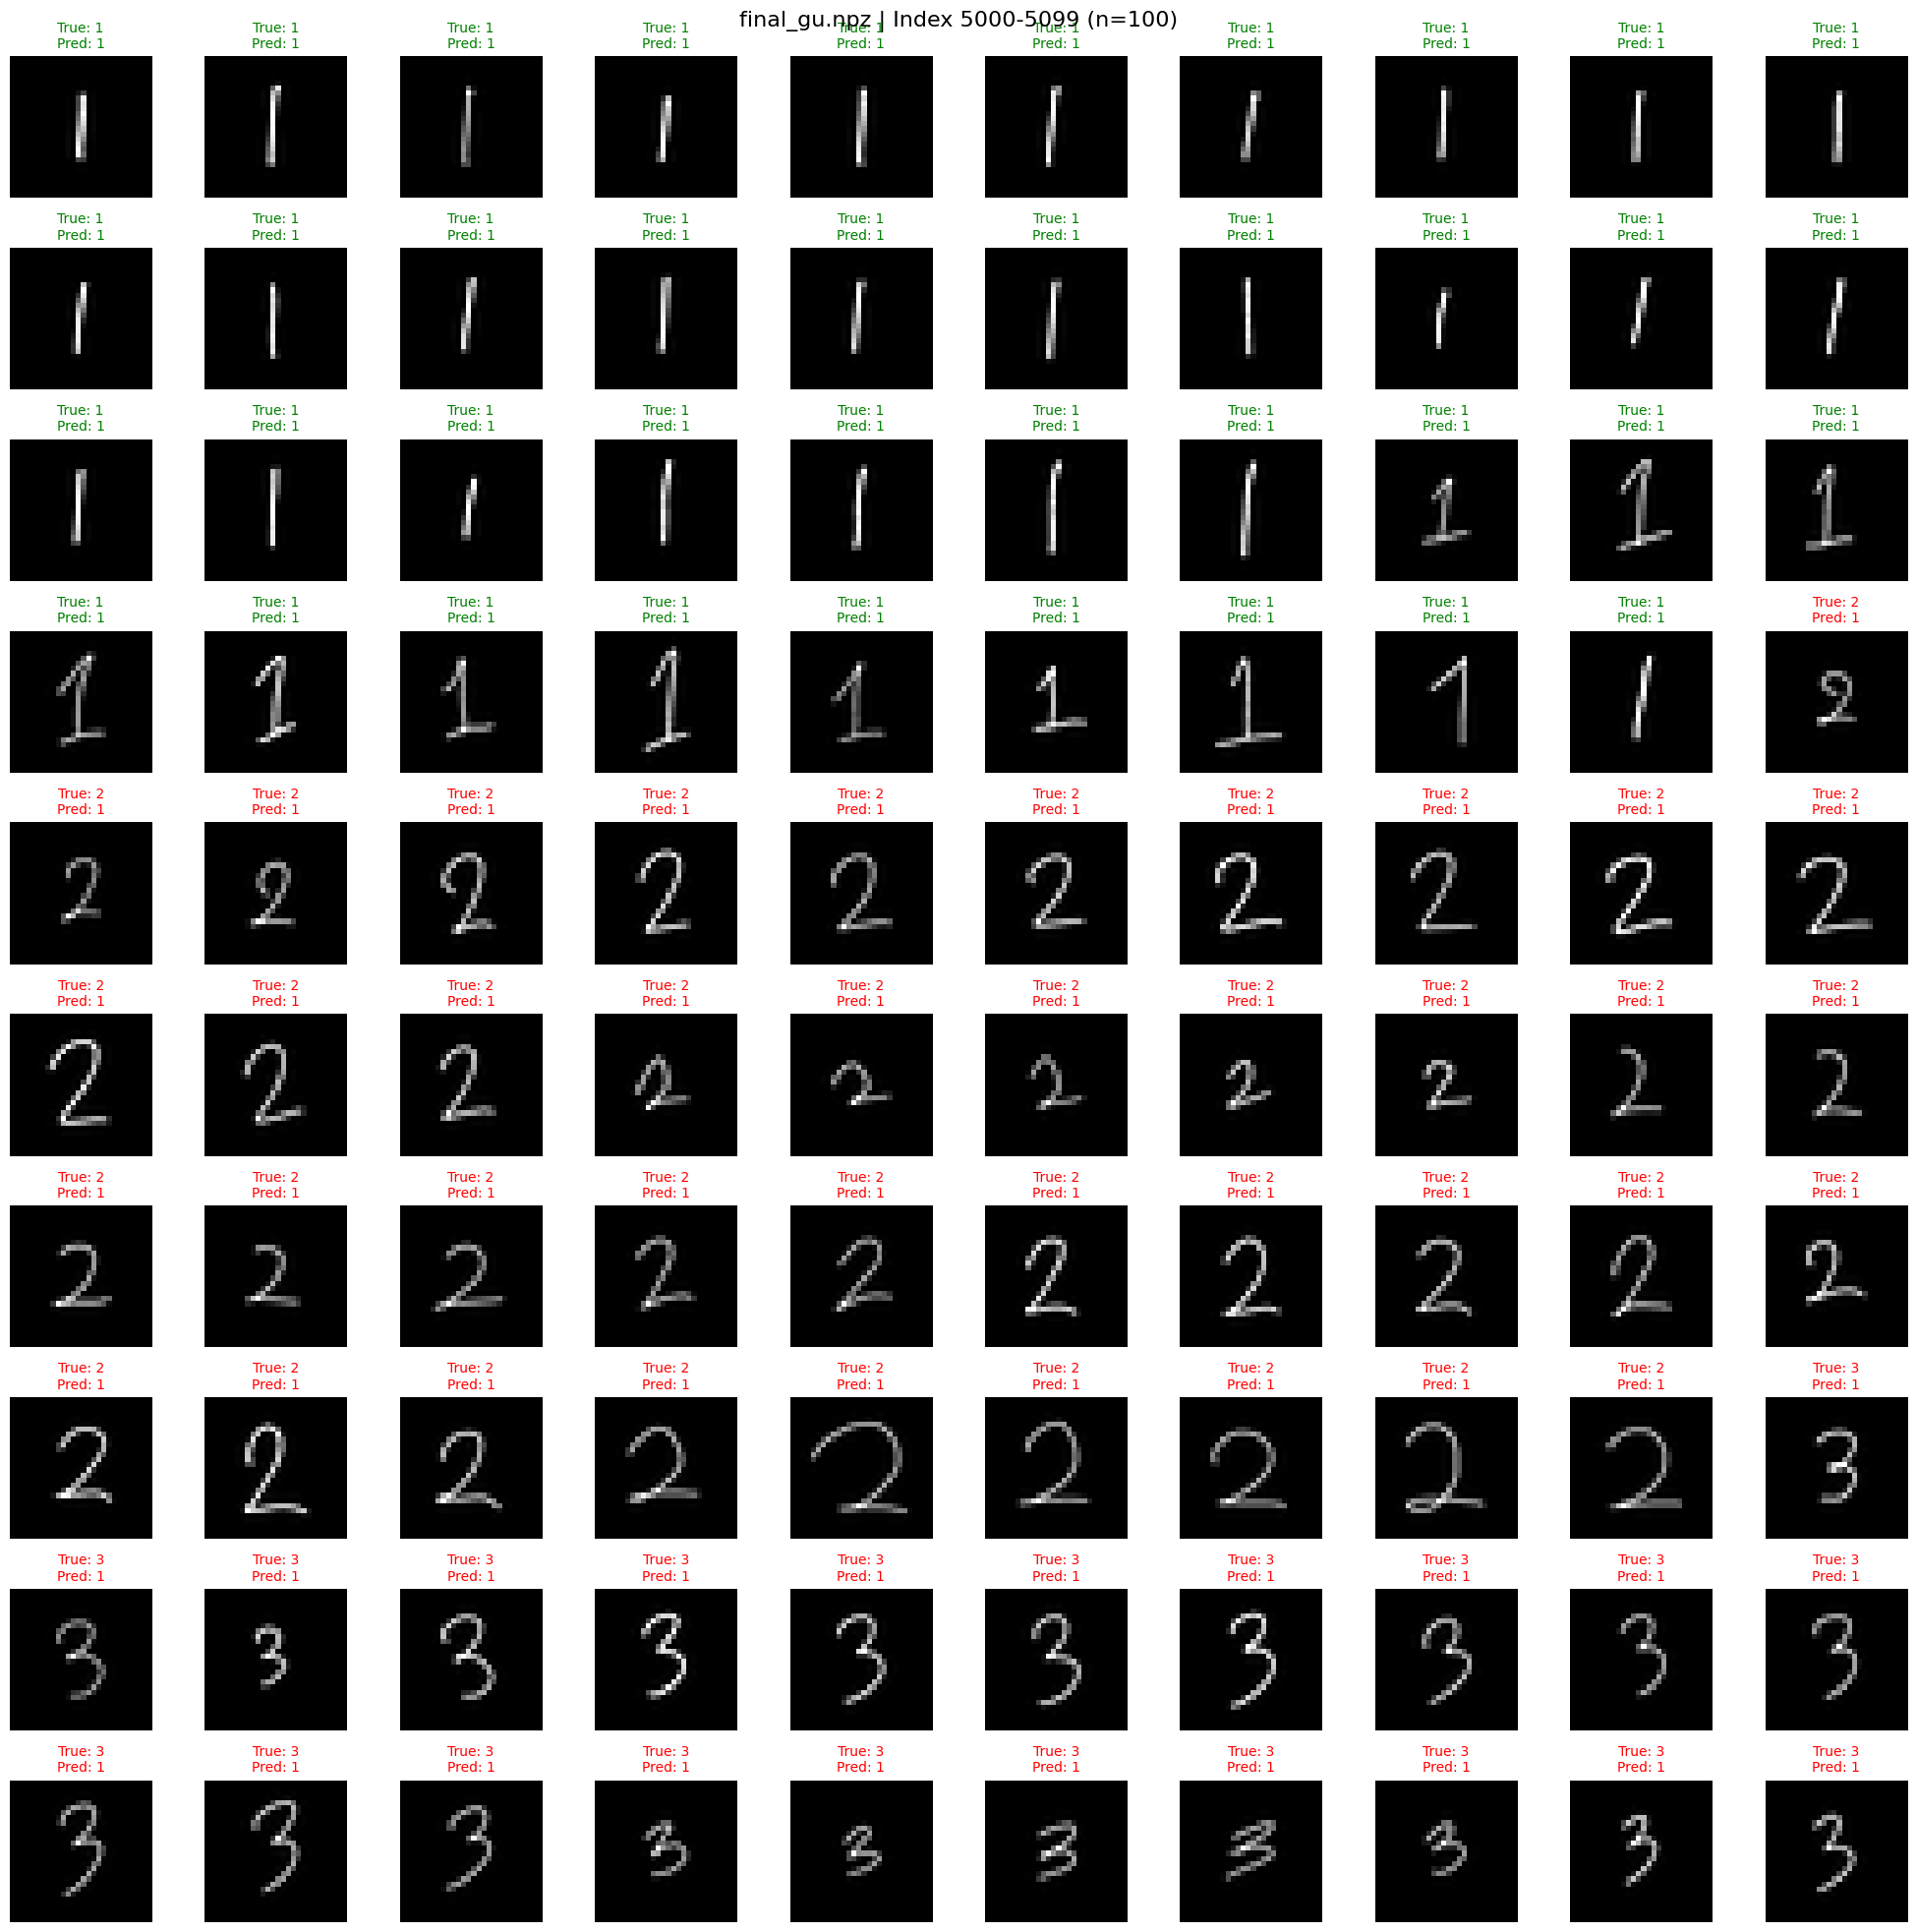

In [ ]:
import numpy as np
import joblib
import os
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 설정 ---
MODEL_FILENAME = '06_logreg_halving.joblib'
DATASETS = [
    "custom_MNIST2.npz",  # 1번 데이터셋
    "final_gu.npz",  # 2번 데이터셋
]

DATA_KEYS_PRIMARY = ("images", "labels")  # 선호 키
DATA_KEYS_FALLBACK = ("X", "y")            # 대체 키

SHOW_START, SHOW_END = 5000, 5099  # 📌 수정: 시각화 구간을 5000-5099로 변경

# -----------------------------
# 유틸 함수
# -----------------------------
def load_npz_dataset(path):
    """
    NPZ 파일에서 (X_3d, y) 반환.
    - 키는 ('images','labels') 우선, 없으면 ('X','y')
    - X가 2D이면 3D로 복원해줌 (시각화용)
    - 값은 0~1 정규화 보장
    """
    npz = np.load(path)
    if all(k in npz.files for k in DATA_KEYS_PRIMARY):
        X = npz[DATA_KEYS_PRIMARY[0]]
        y = npz[DATA_KEYS_PRIMARY[1]]
    elif all(k in npz.files for k in DATA_KEYS_FALLBACK):
        X = npz[DATA_KEYS_FALLBACK[0]]
        y = npz[DATA_KEYS_FALLBACK[1]]
    else:
        raise KeyError(f"NPZ keys not found in {path}. Need one of {DATA_KEYS_PRIMARY} or {DATA_KEYS_FALLBACK}.")

    # 정규화
    if X.max() > 1.0:
        X = X.astype(np.float32)

    # 3D로 보장
    if X.ndim == 2:  # (N, D)
        N, D = X.shape
        side = int(np.sqrt(D))
        if side * side != D:
            raise ValueError(f"Cannot infer square image from flattened size {D}")
        X_3d = X.reshape(N, side, side)
    elif X.ndim == 3:  # (N, H, W)
        X_3d = X
    else:
        raise ValueError(f"Unsupported X shape {X.shape} in {path}")

    return X_3d, y

def visualize_range(images_3d, y_true, y_pred, start_idx, end_idx, title):
    """
    images_3d, y_true, y_pred에서 [start_idx:end_idx] (포함)만 시각화.
    """
    end_idx = min(end_idx, len(images_3d)-1)
    if start_idx > end_idx:
        print(f"[{title}] 시각화 범위가 데이터 길이보다 큽니다. (총 {len(images_3d)}개)")
        return

    sel_imgs = images_3d[start_idx:end_idx+1]
    sel_true = y_true[start_idx:end_idx+1]
    sel_pred = y_pred[start_idx:end_idx+1]
    n = len(sel_imgs)

    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(20, 20))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(sel_imgs[i], cmap='gray')
        color = 'green' if sel_pred[i] == sel_true[i] else 'red'
        axes[i].set_title(f"True: {sel_true[i]}\nPred: {sel_pred[i]}", color=color, fontsize=10)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{title} | Index {start_idx}-{end_idx} (n={n})", fontsize=16)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 1) 모델 로드
# -----------------------------
print(f"Loading model: {MODEL_FILENAME}")
try:
    model = joblib.load(MODEL_FILENAME)
    print("    > 모델 로드 성공.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise SystemExit

# -----------------------------
# 2) 각 NPZ에 대해 예측/정확도/시각화
# -----------------------------
for path in DATASETS:
    if not os.path.exists(path):
        print(f"⚠️ {path} 가 존재하지 않습니다. 건너뜜니다.")
        continue

    print(f"\n✅ NPZ 데이터 로드 중: {path}")
    try:
        X_3d, y_true = load_npz_dataset(path)
        N, H, W = X_3d.shape
        print(f"    > 로드 성공: X={X_3d.shape}, y={y_true.shape} (이미지 {H}x{W})")
    except Exception as e:
        print(f"❌ Error loading data from {path}: {e}")
        continue

    # 평탄화
    X_flat = X_3d.reshape(N, -1)

    # 예측 & 정확도
    print("    > 예측/정확도 계산 중...")
    try:
        y_pred = model.predict(X_flat)
        acc = accuracy_score(y_true, y_pred)
        print("---------------------------------")
        print(f"[{os.path.basename(path)}] Test Accuracy: {acc:.4f}")
        print(f"[{os.path.basename(path)}] Total samples: {len(y_true)}")
        print("---------------------------------")
    except Exception as e:
        print(f"❌ Error during prediction for {path}: {e}")
        continue

    # 5000~5099 구간 시각화
    visualize_range(X_3d, y_true, y_pred, SHOW_START, SHOW_END, title=os.path.basename(path))